# EdNet KT4 — Common-Data, Leakage-Aware Hybrid Sequential Recommendation

## Dissertation-strength, memory-safe rebuild

This notebook implements a **common-data fairness design** for EdNet KT4 and harmonizes the experimental logic with the RetailRocket study without forcing identical dataset sizes or claiming that the two domains have the same interaction density.

### Main design decision

All five constituent families — **CF, RF, GRU4Rec, SASRec, and BERT4Rec-style** — are exposed to the **same deterministic 50,000-learner training cohort** and the same bounded training histories (up to 50 most recent permissible training interactions per learner). The 50,000-learner budget is deliberately substantial for a PhD-level experiment while remaining computationally realistic for the much denser EdNet KT4 event stream.

### Why this notebook is memory-safe

The merged KT4 file contains more than 100 million raw rows. Loading the complete Feather file into a pandas DataFrame can exceed Kaggle RAM and restart the kernel. This rebuild therefore:

1. scans the Feather file **record-batch by record-batch**;
2. filters to recommendable q/e/l content before materializing rows;
3. writes compact temporary Parquet chunks;
4. uses **DuckDB out-of-core SQL with an explicit memory limit and disk spilling** for exact deduplication, chronological consecutive-event collapsing, and learner history counting;
5. selects the common 50k cohort using **training-only history information**;
6. loads only the selected learners' most recent 52 content events (50 permissible training events + validation + test) into pandas.

This preserves the common-data fairness design while avoiding a full 131M-row pandas allocation.

### Publication-validity controls

1. EdNet **KT4** heterogeneous events are explicitly transformed into question/explanation/lecture content sequences.
2. Per-learner chronological leave-two-out splitting isolates training, validation, and test targets.
3. All baseline families receive identical cohort membership and identical bounded histories.
4. RF supervised examples are generated only from temporal prefixes.
5. GRU4Rec, SASRec, and BERT4Rec-style use the same common histories and the same maximum number of prefix cases per learner.
6. Candidate sets are model-independent, cached, and shared across all systems.
7. The validation set is internally divided into **4,000 fusion-fit queries and 1,000 component-selection queries**.
8. Reliability weights are estimated only from the fusion-fit portion.
9. Backward component selection uses only the component-selection portion.
10. The final component set is frozen before the final test is opened.
11. The final XGBRanker is refitted on all 5,000 validation queries after selection.
12. Repeated-seed ablation retrains the fusion ranker.
13. Popularity controls, SHAP attribution, history robustness, paired inference, efficiency profiling, and a controlled neural data-scaling diagnostic are included.
14. Main conclusions are explicitly limited to **sampled ranking**, not full-catalogue retrieval.

> **Important:** run the notebook from top to bottom in Kaggle. Do not use final-test results to redesign the component set or hyperparameters.


In [2]:
# ============================================================
# 1. IMPORTS, REPRODUCIBILITY AND GLOBAL CONFIGURATION
# ============================================================
import os, gc, time, math, random, pickle, tempfile, warnings, hashlib, json, platform, sys
from pathlib import Path
from collections import Counter
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
from tqdm.auto import tqdm

from sklearn.ensemble import RandomForestClassifier
from scipy.stats import wilcoxon, rankdata
from statsmodels.stats.multitest import multipletests

from xgboost import XGBRanker

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
try:
    torch.use_deterministic_algorithms(False)
except Exception:
    pass

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

DATASET_NAME = "ednet_kt4_common50k"
DATA_PATH = "/kaggle/input/datasets/anhtu96/ednet-kt34/KT4_merged.feather"
OUT_DIR = Path("/kaggle/working/ednet_kt4_common50k_publication_outputs")
OUT_DIR.mkdir(parents=True, exist_ok=True)

# --------------------------
# Memory-safe KT4 preprocessing
# --------------------------
DUCKDB_MEMORY_LIMIT = "6GB"     # forces spill-to-disk well before Kaggle RAM exhaustion
DUCKDB_THREADS = 4
STAGE_ROWS_PER_FILE = 500_000
PREPROCESS_CACHE_DIR = Path("/kaggle/working/ednet_kt4_common50k_cache")
PREPROCESS_CACHE_DIR.mkdir(parents=True, exist_ok=True)
REUSE_PREPROCESS_CACHE = True   # safe to keep True when re-running after later-cell errors


# --------------------------
# Common-data design
# --------------------------
COMMON_LEARNERS = 50_000
COMMON_MAX_HISTORY = 50
MAX_PREFIXES_PER_LEARNER = 2
MAX_EVAL_USERS = 5_000
NEGATIVES_PER_QUERY = 99
TOPK = 10
MIN_USER_EVENTS = 3
MIN_COMMON_TRAIN_EVENTS = 2
LEARNING_PREFIXES = {"q", "e", "l"}

# Validation partition used only for design decisions.
FUSION_FIT_QUERIES = 4_000
COMPONENT_SELECTION_QUERIES = 1_000

# --------------------------
# Constituent model budgets
# --------------------------
RF_NEGATIVES_PER_POSITIVE = 1
RF_TREES = 120
RF_MAX_DEPTH = 10
RF_MIN_LEAF = 5

GRU_MAX_LEN = 30
GRU_EMBED = 32
GRU_HIDDEN = 32
GRU_BATCH = 32
GRU_EPOCHS = 15

SAS_MAX_LEN = 30
SAS_HIDDEN = 48
SAS_HEADS = 2
SAS_LAYERS = 1
SAS_BATCH = 64
SAS_EPOCHS = 15

BERT_MAX_LEN = 30
BERT_HIDDEN = 32
BERT_HEADS = 2
BERT_LAYERS = 1
BERT_BATCH = 24
BERT_EPOCHS = 15

# Harmonized ranker specification. It is fixed before final-test evaluation.
RANKER_PARAMS = dict(
    objective="rank:ndcg",
    eval_metric="ndcg@10",
    n_estimators=300,
    learning_rate=0.035,
    max_depth=5,
    min_child_weight=8,
    subsample=0.80,
    colsample_bytree=0.80,
    reg_alpha=1.5,
    reg_lambda=10.0,
    gamma=0.15,
    tree_method="hist",
    n_jobs=4,
)

# Controlled scaling diagnostic. Disable only for debugging; publication run should keep True.
RUN_SCALING_DIAGNOSTIC = True
SCALING_COHORTS = [10_000, 25_000, 50_000]
SCALING_EPOCHS = 6
SCALING_EVAL_USERS = 1_000

print("Dataset:", DATASET_NAME)
print("Device:", DEVICE)
print("Common learner budget:", f"{COMMON_LEARNERS:,}")
print("Common history cap:", COMMON_MAX_HISTORY)
print("Max training prefixes per learner:", MAX_PREFIXES_PER_LEARNER)
print("Output directory:", OUT_DIR)

Dataset: ednet_kt4_common50k
Device: cuda
Common learner budget: 50,000
Common history cap: 50
Max training prefixes per learner: 2
Output directory: /kaggle/working/ednet_kt4_common50k_publication_outputs


## Kaggle execution note

If an earlier version showed **“Your notebook tried to allocate more memory than is available”**, the crash occurred because the full KT4 Feather file was being loaded into pandas. This version does not do that.

For the first complete run:

- use a **GPU session**;
- keep Internet off unless you need it for package installation;
- run **Run All** from a fresh kernel;
- do not open multiple copies of the same notebook session;
- allow Cell 2 to finish even if it takes time — it is doing out-of-core preprocessing and may spill to `/kaggle/working`;
- after Cell 2 completes once, `REUSE_PREPROCESS_CACHE=True` lets later reruns reuse the normalized cache.

If the session is interrupted after Cell 2, restart and rerun: the cache will be reused rather than rescanning the full KT4 source.


In [3]:
# ============================================================
# 2. MEMORY-SAFE KT4 PREPROCESSING + TRAIN-ONLY 50K COHORT SELECTION
# ============================================================
# IMPORTANT:
# Do NOT replace this cell with pd.read_feather(DATA_PATH).
# KT4 is too large for a full pandas materialization on Kaggle RAM.

import pyarrow as pa
import pyarrow.ipc as ipc
import pyarrow.parquet as pq
from collections import Counter
import shutil

try:
    import duckdb
except ImportError as e:
    raise ImportError(
        "DuckDB is required for the memory-safe KT4 preprocessing stage. "
        "Kaggle normally provides it. If your image does not, install `duckdb` once and restart."
    ) from e

if not os.path.exists(DATA_PATH):
    matches = list(Path("/kaggle/input").rglob("KT4_merged.feather"))
    if not matches:
        raise FileNotFoundError(
            f"KT4_merged.feather not found at {DATA_PATH} and no fallback copy was found under /kaggle/input."
        )
    DATA_PATH = str(matches[0])
    print("Using fallback KT4 path:", DATA_PATH)

stage_dir = PREPROCESS_CACHE_DIR / "filtered_qel_stage"
normalized_path = PREPROCESS_CACHE_DIR / "kt4_qel_normalized.parquet"
counts_path = PREPROCESS_CACHE_DIR / "kt4_user_counts.parquet"

def _safe_rmtree(p):
    p = Path(p)
    if p.exists():
        shutil.rmtree(p, ignore_errors=True)

def _flush_stage(buffer, file_no):
    if not buffer:
        return file_no, 0
    part = pd.concat(buffer, ignore_index=True)
    out_file = stage_dir / f"part_{file_no:05d}.parquet"
    part.to_parquet(out_file, index=False, engine="pyarrow", compression="zstd")
    n = len(part)
    del part
    buffer.clear()
    gc.collect()
    return file_no + 1, n

# ------------------------------------------------------------------
# A. Stream the 131M-row Feather source in Arrow record batches.
#    Only q/e/l rows are staged; the raw table never becomes a pandas DF.
# ------------------------------------------------------------------
need_build_normalized = not (REUSE_PREPROCESS_CACHE and normalized_path.exists() and counts_path.exists())

raw_rows = 0
raw_user_ids = set()
action_counter = Counter()
filtered_before_collapse = 0

if need_build_normalized:
    _safe_rmtree(stage_dir)
    stage_dir.mkdir(parents=True, exist_ok=True)
    if normalized_path.exists():
        normalized_path.unlink()
    if counts_path.exists():
        counts_path.unlink()

    with pa.memory_map(DATA_PATH, "r") as source:
        reader = ipc.open_file(source)
        schema_names = reader.schema.names

        required = {"user_id", "item_id", "timestamp"}
        missing = required - set(schema_names)
        if missing:
            raise ValueError(f"Required KT4 columns missing: {missing}")

        load_cols = ["user_id", "item_id", "timestamp"]
        if "action_type" in schema_names:
            load_cols.append("action_type")

        print("Feather record batches:", reader.num_record_batches)
        print("Streaming columns:", load_cols)

        buffer = []
        buffered_rows = 0
        file_no = 0
        global_offset = 0

        for bi in tqdm(range(reader.num_record_batches), desc="Streaming KT4 batches"):
            rb = reader.get_batch(bi)
            n_batch = rb.num_rows
            raw_rows += n_batch

            # Convert only the needed columns for this record batch.
            data = {}
            for c in load_cols:
                arr = rb.column(reader.schema.get_field_index(c))
                data[c] = arr.to_pandas()
            b = pd.DataFrame(data)

            # Raw user count is cheap because KT4 has only ~300k users.
            if "user_id" in b:
                raw_user_ids.update(b["user_id"].dropna().astype(str).tolist())

            if "action_type" in b.columns:
                vc = b["action_type"].astype("string").value_counts(dropna=False)
                for k, v in vc.items():
                    action_counter[str(k)] += int(v)

            b = b.dropna(subset=["user_id", "item_id", "timestamp"])
            if len(b) == 0:
                global_offset += n_batch
                continue

            # Normalize identifiers only inside the current batch.
            b["user_id"] = b["user_id"].astype("string").str.strip()
            b["item_id"] = b["item_id"].astype("string").str.strip()
            b["timestamp"] = pd.to_numeric(b["timestamp"], errors="coerce")
            b = b.dropna(subset=["timestamp"])
            if len(b) == 0:
                global_offset += n_batch
                continue
            b["timestamp"] = b["timestamp"].astype(np.int64)

            prefix = b["item_id"].str[0].str.lower()
            keep = prefix.isin(LEARNING_PREFIXES)
            if not keep.any():
                global_offset += n_batch
                del b
                gc.collect()
                continue

            q = b.loc[keep, ["user_id", "item_id", "timestamp"]].copy()
            # Preserve a deterministic raw-row tie breaker for equal timestamps.
            q["source_row"] = (
                global_offset + np.flatnonzero(keep.to_numpy())
            ).astype(np.int64)

            filtered_before_collapse += len(q)
            buffer.append(q)
            buffered_rows += len(q)

            if buffered_rows >= STAGE_ROWS_PER_FILE:
                file_no, _ = _flush_stage(buffer, file_no)
                buffered_rows = 0

            global_offset += n_batch
            del b, q
            gc.collect()

        if buffer:
            file_no, _ = _flush_stage(buffer, file_no)

    raw_users = len(raw_user_ids)
    print(f"Raw rows scanned: {raw_rows:,}")
    print(f"Raw users observed: {raw_users:,}")
    print(f"q/e/l rows before exact/consecutive collapse: {filtered_before_collapse:,}")
    print(f"Temporary Parquet parts: {file_no:,}")

    # ------------------------------------------------------------------
    # B. Out-of-core normalization in DuckDB.
    #    The explicit 6GB memory limit prevents the OS from killing Python.
    # ------------------------------------------------------------------
    tmp_spill = PREPROCESS_CACHE_DIR / "duckdb_spill"
    tmp_spill.mkdir(parents=True, exist_ok=True)

    con = duckdb.connect(database=str(PREPROCESS_CACHE_DIR / "kt4_preprocess.duckdb"))
    con.execute(f"SET memory_limit='{DUCKDB_MEMORY_LIMIT}'")
    con.execute(f"SET threads={DUCKDB_THREADS}")
    con.execute(f"SET temp_directory='{str(tmp_spill)}'")
    con.execute("SET preserve_insertion_order=false")

    stage_glob = str(stage_dir / "*.parquet").replace("\\", "/")
    norm_file = str(normalized_path).replace("\\", "/")
    count_file = str(counts_path).replace("\\", "/")

    print("Building exact-deduplicated, consecutive-collapsed q/e/l event table out-of-core...")

    normalize_sql = f"""
    COPY (
        WITH exact_marked AS (
            SELECT
                user_id,
                item_id,
                CAST(timestamp AS BIGINT) AS timestamp,
                CAST(source_row AS BIGINT) AS source_row,
                ROW_NUMBER() OVER (
                    PARTITION BY user_id, item_id, timestamp
                    ORDER BY source_row
                ) AS dup_rn
            FROM read_parquet('{stage_glob}')
        ),
        exact_dedup AS (
            SELECT user_id, item_id, timestamp, source_row
            FROM exact_marked
            WHERE dup_rn = 1
        ),
        with_prev AS (
            SELECT
                user_id,
                item_id,
                timestamp,
                source_row,
                LAG(item_id) OVER (
                    PARTITION BY user_id
                    ORDER BY timestamp, source_row
                ) AS prev_item
            FROM exact_dedup
        )
        SELECT user_id, item_id, timestamp, source_row
        FROM with_prev
        WHERE prev_item IS NULL OR item_id <> prev_item
    )
    TO '{norm_file}'
    (FORMAT PARQUET, COMPRESSION ZSTD, ROW_GROUP_SIZE 250000)
    """
    con.execute(normalize_sql)

    # Per-user event counts after all semantic normalization.
    con.execute(f"""
        COPY (
            SELECT user_id, COUNT(*)::BIGINT AS n_events
            FROM read_parquet('{norm_file}')
            GROUP BY user_id
        )
        TO '{count_file}'
        (FORMAT PARQUET, COMPRESSION ZSTD)
    """)

    # The normalized Parquet is now sufficient; remove bulky stage chunks.
    _safe_rmtree(stage_dir)
    gc.collect()

    # Save raw scan metadata separately because it is not derivable from normalized rows.
    raw_meta = {
        "raw_rows": int(raw_rows),
        "raw_users": int(raw_users),
        "filtered_qel_before_collapse": int(filtered_before_collapse),
        "action_counts": dict(action_counter),
    }
    with open(PREPROCESS_CACHE_DIR / "raw_scan_metadata.json", "w", encoding="utf-8") as f:
        json.dump(raw_meta, f)

    con.close()
    del raw_user_ids
    gc.collect()

else:
    print("Reusing memory-safe preprocessing cache:", PREPROCESS_CACHE_DIR)
    meta_file = PREPROCESS_CACHE_DIR / "raw_scan_metadata.json"
    if meta_file.exists():
        with open(meta_file, "r", encoding="utf-8") as f:
            raw_meta = json.load(f)
        raw_rows = int(raw_meta.get("raw_rows", 0))
        raw_users = int(raw_meta.get("raw_users", 0))
        filtered_before_collapse = int(raw_meta.get("filtered_qel_before_collapse", 0))
        action_counter = Counter(raw_meta.get("action_counts", {}))
    else:
        raw_rows = raw_users = filtered_before_collapse = 0
        action_counter = Counter()

# ------------------------------------------------------------------
# C. Global train-only history-length table (small: one row per learner).
# ------------------------------------------------------------------
user_counts = pd.read_parquet(counts_path)
user_counts["user_id"] = user_counts["user_id"].astype("string")
user_counts["n_events"] = user_counts["n_events"].astype(np.int64)

# Need validation + test + at least MIN_COMMON_TRAIN_EVENTS permissible training events.
train_lengths = user_counts[user_counts["n_events"] >= (MIN_COMMON_TRAIN_EVENTS + 2)].copy()
train_lengths["train_len"] = train_lengths["n_events"] - 2

def history_stratum(n):
    n = int(n)
    if n <= 5: return "<=5"
    if n <= 20: return "6-20"
    if n <= 50: return "21-50"
    if n <= 100: return "51-100"
    return ">100"

train_lengths["stratum"] = train_lengths["train_len"].map(history_stratum)
eligible_n = len(train_lengths)
if eligible_n < COMMON_LEARNERS:
    raise ValueError(
        f"Only {eligible_n:,} learners have >= {MIN_COMMON_TRAIN_EVENTS} permissible "
        f"training events; requested {COMMON_LEARNERS:,}."
    )

# ------------------------------------------------------------------
# D. Deterministic proportional stratified common-50k selection.
#    Selection uses TRAINING-HISTORY LENGTH ONLY.
# ------------------------------------------------------------------
counts_by_stratum = train_lengths["stratum"].value_counts().sort_index()
ideal = counts_by_stratum / counts_by_stratum.sum() * COMMON_LEARNERS
quota = np.floor(ideal).astype(int)
remainder = COMMON_LEARNERS - int(quota.sum())
if remainder > 0:
    frac = (ideal - quota).sort_values(ascending=False)
    for s in frac.index[:remainder]:
        quota.loc[s] += 1

rng = np.random.default_rng(SEED)
selected_original = []
for s, q in quota.items():
    pool = train_lengths.loc[
        train_lengths["stratum"] == s, "user_id"
    ].astype(str).to_numpy()
    q = min(int(q), len(pool))
    selected_original.extend(rng.choice(pool, size=q, replace=False).tolist())

selected_original = set(map(str, selected_original))
if len(selected_original) < COMMON_LEARNERS:
    remaining = train_lengths.loc[
        ~train_lengths["user_id"].astype(str).isin(selected_original), "user_id"
    ].astype(str).to_numpy()
    extra = rng.choice(
        remaining, size=COMMON_LEARNERS-len(selected_original), replace=False
    )
    selected_original.update(map(str, extra))
elif len(selected_original) > COMMON_LEARNERS:
    selected_original = set(
        rng.choice(
            np.array(sorted(selected_original), dtype=object),
            size=COMMON_LEARNERS, replace=False
        ).tolist()
    )

selected_original = np.array(sorted(selected_original), dtype=object)
assert len(selected_original) == COMMON_LEARNERS

COMMON_COHORT_ORIGINAL_SHA256 = hashlib.sha256(
    ",".join(map(str, selected_original.tolist())).encode("utf-8")
).hexdigest()

# ------------------------------------------------------------------
# E. Load ONLY the selected learners' latest 52 normalized events.
#    50 train + validation + test is sufficient for the entire common-data design.
# ------------------------------------------------------------------
con = duckdb.connect(database=":memory:")
con.execute(f"SET memory_limit='{DUCKDB_MEMORY_LIMIT}'")
con.execute(f"SET threads={DUCKDB_THREADS}")
spill_dir = PREPROCESS_CACHE_DIR / "duckdb_spill_selected"
spill_dir.mkdir(parents=True, exist_ok=True)
con.execute(f"SET temp_directory='{str(spill_dir)}'")
con.execute("SET preserve_insertion_order=false")

selected_df = pd.DataFrame({"user_id": pd.Series(selected_original, dtype="string")})
con.register("selected_users", selected_df)
norm_file = str(normalized_path).replace("\\", "/")

latest_needed = COMMON_MAX_HISTORY + 2

compact = con.execute(f"""
    WITH joined AS (
        SELECT e.user_id, e.item_id, e.timestamp, e.source_row
        FROM read_parquet('{norm_file}') e
        INNER JOIN selected_users s
            ON e.user_id = s.user_id
    ),
    ranked AS (
        SELECT
            user_id,
            item_id,
            timestamp,
            source_row,
            ROW_NUMBER() OVER (
                PARTITION BY user_id
                ORDER BY timestamp DESC, source_row DESC
            ) AS rn_desc
        FROM joined
    )
    SELECT user_id, item_id, timestamp, source_row
    FROM ranked
    WHERE rn_desc <= {latest_needed}
    ORDER BY user_id, timestamp, source_row
""").df()

con.close()
del selected_df
gc.collect()

if compact["user_id"].nunique() != COMMON_LEARNERS:
    raise RuntimeError(
        f"Expected {COMMON_LEARNERS:,} selected learners but loaded "
        f"{compact['user_id'].nunique():,}."
    )

# Encode only after the common cohort is frozen.
compact["user_id"] = compact["user_id"].astype("category")
compact["item_id"] = compact["item_id"].astype("category")
compact["user_idx"] = compact["user_id"].cat.codes.astype(np.int32)
compact["item_idx"] = compact["item_id"].cat.codes.astype(np.int32) + 1
compact["item_prefix"] = compact["item_id"].astype(str).str[0].str.lower()

item_id_lookup = dict(
    zip(compact["item_idx"].astype(int), compact["item_id"].astype(str))
)
item_type_lookup = {k: v[0].lower() for k, v in item_id_lookup.items()}

df = (
    compact[["user_idx", "item_idx", "timestamp", "item_prefix"]]
    .sort_values(["user_idx", "timestamp"], kind="mergesort")
    .reset_index(drop=True)
)
n_items = int(df["item_idx"].max()) + 1

# Global normalized statistics are computed out-of-core.
con = duckdb.connect(database=":memory:")
con.execute(f"SET memory_limit='{DUCKDB_MEMORY_LIMIT}'")
con.execute(f"SET threads={DUCKDB_THREADS}")
norm_stats = con.execute(f"""
    SELECT
        COUNT(*)::BIGINT AS normalized_events,
        COUNT(DISTINCT user_id)::BIGINT AS normalized_users,
        COUNT(DISTINCT item_id)::BIGINT AS normalized_items
    FROM read_parquet('{norm_file}')
""").df().iloc[0]
con.close()

action_audit = pd.DataFrame(
    sorted(action_counter.items(), key=lambda kv: kv[1], reverse=True),
    columns=["action_type", "raw_count"]
)
if len(action_audit):
    display(action_audit.head(30))
    action_audit.to_csv(OUT_DIR / "kt4_raw_action_type_counts.csv", index=False)

preprocess_audit = pd.DataFrame([
    ["Raw KT4 merged rows", raw_rows if raw_rows else "cached"],
    ["Raw KT4 users", raw_users if raw_users else "cached"],
    ["q/e/l rows before exact/consecutive collapse",
     filtered_before_collapse if filtered_before_collapse else "cached"],
    ["Normalized q/e/l content events", int(norm_stats["normalized_events"])],
    ["Normalized q/e/l users", int(norm_stats["normalized_users"])],
    ["Normalized q/e/l items", int(norm_stats["normalized_items"])],
    ["Eligible learners for common-cohort selection", int(eligible_n)],
    ["Selected common learners", int(COMMON_LEARNERS)],
    ["Loaded compact rows (max 52/learner)", int(len(df))],
], columns=["Statistic", "Value"])

display(preprocess_audit)
display(df["item_prefix"].value_counts().rename("loaded_events").to_frame())
preprocess_audit.to_csv(OUT_DIR / "kt4_preprocessing_audit.csv", index=False)

del compact, user_counts
gc.collect()

print("COMMON_COHORT_ORIGINAL_SHA256:", COMMON_COHORT_ORIGINAL_SHA256)
print("Memory-safe preprocessing complete.")


Feather record batches: 2006
Streaming columns: ['user_id', 'item_id', 'timestamp', 'action_type']


Streaming KT4 batches:   0%|          | 0/2006 [00:00<?, ?it/s]

Raw rows scanned: 131,441,538
Raw users observed: 297,915
q/e/l rows before exact/consecutive collapse: 64,976,872
Temporary Parquet parts: 126
Building exact-deduplicated, consecutive-collapsed q/e/l event table out-of-core...


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,action_type,raw_count
0,enter,32943087
1,respond,23384480
2,pause_audio,16879046
3,play_audio,16580464
4,submit,16488061
5,quit,16455026
6,erase_choice,4714534
7,play_video,1928356
8,pause_video,1898080
9,undo_erase_choice,142092


,Statistic,Value
0,Raw KT4 merged rows,131441538
1,Raw KT4 users,297915
2,q/e/l rows before exact/consecutive collapse,64976872
3,Normalized q/e/l content events,34052376
4,Normalized q/e/l users,297855
5,Normalized q/e/l items,21022
6,Eligible learners for common-cohort selection,274928
7,Selected common learners,50000
8,Loaded compact rows (max 52/learner),970981


,loaded_events
item_prefix,
q,626619
e,332405
l,11957


COMMON_COHORT_ORIGINAL_SHA256: 6bf99049d163e8c413da16f8a08f610d3ff12da2cc3432738479f435b8343e97
Memory-safe preprocessing complete.


In [4]:
# ============================================================
# 3. CHRONOLOGICAL LEAVE-TWO-OUT SPLIT ON THE FROZEN COMMON COHORT
# ============================================================
# The in-memory table contains at most 52 latest normalized content events/learner:
# up to 50 permissible train events + validation target + test target.

last2 = df.groupby("user_idx", sort=False, group_keys=False).tail(2)
test_idx = last2.groupby("user_idx", sort=False, group_keys=False).tail(1).index
val_idx = last2.drop(index=test_idx).index

full_train_df = (
    df.drop(index=np.concatenate([val_idx.to_numpy(), test_idx.to_numpy()]))
    .reset_index(drop=True)
)
val_df = df.loc[val_idx].reset_index(drop=True)
test_df = df.loc[test_idx].reset_index(drop=True)

# Because only the latest 52 events were loaded, each common learner has <=50 training events.
assert full_train_df.groupby("user_idx").size().max() <= COMMON_MAX_HISTORY
assert full_train_df["user_idx"].nunique() == COMMON_LEARNERS
assert val_df["user_idx"].nunique() == COMMON_LEARNERS
assert test_df["user_idx"].nunique() == COMMON_LEARNERS

# Chronology assertions.
tr_max = full_train_df.groupby("user_idx")["timestamp"].max()
va_t = val_df.set_index("user_idx")["timestamp"]
te_t = test_df.set_index("user_idx")["timestamp"]
chron_users = tr_max.index.intersection(va_t.index).intersection(te_t.index)

assert (tr_max.loc[chron_users] <= va_t.loc[chron_users]).all(), \
    "Train/validation chronology violated."
assert (va_t.loc[chron_users] <= te_t.loc[chron_users]).all(), \
    "Validation/test chronology violated."

split_audit = pd.DataFrame([
    ["Common-cohort bounded training events", len(full_train_df)],
    ["Validation targets", len(val_df)],
    ["Test targets", len(test_df)],
    ["Common learners", full_train_df["user_idx"].nunique()],
    ["Maximum permissible train events/learner",
     int(full_train_df.groupby("user_idx").size().max())],
], columns=["Statistic", "Value"])

display(split_audit)
split_audit.to_csv(OUT_DIR / "kt4_common50k_split_audit.csv", index=False)


,Statistic,Value
0,Common-cohort bounded training events,870981
1,Validation targets,50000
2,Test targets,50000
3,Common learners,50000
4,Maximum permissible train events/learner,50


In [5]:
# ============================================================
# 4. COMMON 50K TRAINING STRUCTURES + REPRESENTATIVENESS AUDIT
# ============================================================
# Cohort membership was already frozen in Cell 2 using only global training-history length.
# Every model now receives the exact same bounded training rows.

common_train_df = full_train_df.copy()
common_users = np.sort(
    common_train_df["user_idx"].astype(np.int64).unique()
)
assert len(common_users) == COMMON_LEARNERS

common_train_seq = (
    common_train_df.groupby("user_idx", sort=False)["item_idx"]
    .apply(lambda x: list(map(int, x)))
    .to_dict()
)
assert set(common_train_seq.keys()) == set(map(int, common_users))

# Common training catalogue is the ONLY source of evaluation negatives.
train_catalog = np.sort(
    common_train_df["item_idx"].unique().astype(np.int64)
)
train_catalog_set = set(train_catalog.tolist())

# Exact numeric cohort fingerprint used by the downstream fairness gate.
cohort_bytes = ",".join(map(str, common_users.tolist())).encode("utf-8")
COMMON_COHORT_SHA256 = hashlib.sha256(cohort_bytes).hexdigest()

# Common-history fingerprint includes learner code + chronological bounded train sequence.
h = hashlib.sha256()
for uid in common_users:
    seq = common_train_seq[int(uid)]
    h.update(f"{int(uid)}:".encode())
    h.update(",".join(map(str, seq)).encode())
    h.update(b";")
COMMON_HISTORY_SHA256 = h.hexdigest()

# Representativeness audit against ALL globally eligible learners, using uncapped
# pre-validation training-history lengths computed out-of-core.
selected_original_set = set(map(str, selected_original.tolist()))
cohort_lengths = train_lengths[
    train_lengths["user_id"].astype(str).isin(selected_original_set)
].copy()

def dist_summary(x):
    x = np.asarray(x, dtype=float)
    return {
        "n": len(x),
        "mean": x.mean(),
        "median": np.median(x),
        "p25": np.quantile(x, .25),
        "p75": np.quantile(x, .75),
        "p90": np.quantile(x, .90),
        "p99": np.quantile(x, .99),
    }

distribution_audit = pd.DataFrame([
    {"Population": "All eligible", **dist_summary(train_lengths["train_len"])},
    {"Population": "Common 50k", **dist_summary(cohort_lengths["train_len"])},
])
display(distribution_audit)

stratum_audit = pd.concat([
    train_lengths["stratum"].value_counts(normalize=True).rename("Eligible proportion"),
    cohort_lengths["stratum"].value_counts(normalize=True).rename("Common50k proportion"),
], axis=1).fillna(0).sort_index()
display(stratum_audit)

print("Common cohort users:", f"{len(common_users):,}")
print("Common bounded training interactions:", f"{len(common_train_df):,}")
print("Common training catalogue items:", f"{len(train_catalog):,}")
print("COMMON_COHORT_ORIGINAL_SHA256:", COMMON_COHORT_ORIGINAL_SHA256)
print("COMMON_COHORT_SHA256:", COMMON_COHORT_SHA256)
print("COMMON_HISTORY_SHA256:", COMMON_HISTORY_SHA256)

distribution_audit.to_csv(
    OUT_DIR/"kt4_common50k_distribution_audit.csv", index=False
)
stratum_audit.to_csv(
    OUT_DIR/"kt4_common50k_stratum_audit.csv"
)

# No longer needed as large-ish global tables.
del cohort_lengths
gc.collect()


,Population,n,mean,median,p25,p75,p90,p99
0,All eligible,274928,121.704708,7.0,4.0,30.0,204.0,2270.00
1,Common 50k,50000,119.752280,7.0,4.0,29.0,204.0,2232.01


,Eligible proportion,Common50k proportion
stratum,,
21-50,0.100244,0.10024
51-100,0.051592,0.05160
6-20,0.287864,0.28786
<=5,0.414025,0.41402
>100,0.146275,0.14628


Common cohort users: 50,000
Common bounded training interactions: 870,981
Common training catalogue items: 20,688
COMMON_COHORT_ORIGINAL_SHA256: 6bf99049d163e8c413da16f8a08f610d3ff12da2cc3432738479f435b8343e97
COMMON_COHORT_SHA256: 20d955083da5e4d754ae1b14007c11708069624d60d6177d37831503bd7fc543
COMMON_HISTORY_SHA256: f8d8bf4fc55c7e6525d1a7ab68a52914b31f93c81f3e3cc160833df9fdb53cc2


0

In [6]:
# ============================================================
# 5. FROZEN 5,000-LEARNER EVALUATION SAMPLE FROM THE COMMON COHORT
# ============================================================
# Evaluation users must be members of the common training cohort and both held-out
# targets must be known to the common training catalogue.

val_common = val_df[val_df["user_idx"].isin(common_users)].copy()
test_common = test_df[test_df["user_idx"].isin(common_users)].copy()

valid_eval_users = set(
    val_common[val_common["item_idx"].isin(train_catalog_set)]["user_idx"].astype(int)
)
valid_eval_users &= set(
    test_common[test_common["item_idx"].isin(train_catalog_set)]["user_idx"].astype(int)
)
valid_eval_users = np.array(sorted(valid_eval_users), dtype=np.int64)

if len(valid_eval_users) < MAX_EVAL_USERS:
    raise ValueError(
        f"Only {len(valid_eval_users):,} common-cohort learners have train-known validation/test targets; "
        f"{MAX_EVAL_USERS:,} are required."
    )

rng_eval = np.random.default_rng(SEED + 100)
eval_users = np.sort(rng_eval.choice(valid_eval_users, size=MAX_EVAL_USERS, replace=False))

EVAL_USERS_SHA256 = hashlib.sha256(
    ",".join(map(str, eval_users.tolist())).encode("utf-8")
).hexdigest()

val_eval = (
    val_common[val_common["user_idx"].isin(eval_users)]
    .sort_values("user_idx")
    .reset_index(drop=True)
)
test_eval = (
    test_common[test_common["user_idx"].isin(eval_users)]
    .sort_values("user_idx")
    .reset_index(drop=True)
)

# Validation history = common bounded training history.
val_history = {int(u): list(common_train_seq[int(u)]) for u in eval_users}

# Test history = same common bounded training history + validation target, still bounded.
val_target_map = dict(zip(val_eval["user_idx"].astype(int), val_eval["item_idx"].astype(int)))
test_history = {}
for u in eval_users:
    hist = list(common_train_seq[int(u)]) + [int(val_target_map[int(u)])]
    test_history[int(u)] = hist[-COMMON_MAX_HISTORY:]

assert val_eval["user_idx"].nunique() == test_eval["user_idx"].nunique() == MAX_EVAL_USERS
assert set(val_eval["user_idx"].astype(int)) == set(test_eval["user_idx"].astype(int))
assert set(eval_users).issubset(set(common_users))

eval_audit = pd.DataFrame([
    ["Common cohort", COMMON_LEARNERS],
    ["Common bounded training interactions", len(common_train_df)],
    ["Common catalogue items", len(train_catalog)],
    ["Train-known eligible evaluation users", len(valid_eval_users)],
    ["Frozen evaluation users", len(eval_users)],
], columns=["Statistic","Value"])
display(eval_audit)

print("EVAL_USERS_SHA256:", EVAL_USERS_SHA256)
eval_audit.to_csv(OUT_DIR/"kt4_common50k_eval_audit.csv", index=False)

,Statistic,Value
0,Common cohort,50000
1,Common bounded training interactions,870981
2,Common catalogue items,20688
3,Train-known eligible evaluation users,49968
4,Frozen evaluation users,5000


EVAL_USERS_SHA256: 307ac2f112d9392062abc26cd23de8c4fa971b44cd9c6e334ebada768a0c5d22


In [7]:
# ============================================================
# 6. MODEL-INDEPENDENT CACHED 1+99 CANDIDATE PROTOCOL
# ============================================================
def make_candidate_set(uid, truth, history_map, split_name):
    uid, truth = int(uid), int(truth)
    seen = set(map(int, history_map.get(uid, [])))
    split_offset = 1_000_003 if split_name == "test" else 0
    local_seed = (SEED * 10_000_019 + uid * 1009 + truth * 9176 + split_offset) % (2**32 - 1)
    rr = np.random.default_rng(local_seed)

    # Efficient deterministic rejection sampling. With <=50 seen items and ~21k catalogue
    # items, acceptance is very high and avoids materializing a 21k eligible pool per query.
    neg_set = set()
    attempts = 0
    max_attempts = 100_000
    while len(neg_set) < NEGATIVES_PER_QUERY:
        need = NEGATIVES_PER_QUERY - len(neg_set)
        draws = rr.choice(train_catalog, size=max(need * 2, 128), replace=True)
        for x in draws:
            x = int(x)
            if x != truth and x not in seen and x not in neg_set:
                neg_set.add(x)
                if len(neg_set) == NEGATIVES_PER_QUERY:
                    break
        attempts += len(draws)
        if attempts > max_attempts:
            raise RuntimeError(f"Could not generate {NEGATIVES_PER_QUERY} negatives for user {uid}.")
    neg = np.array(sorted(neg_set), dtype=np.int64)
    rr.shuffle(neg)
    candidates = np.concatenate(([truth], neg)).astype(np.int64)
    rr.shuffle(candidates)

    assert len(candidates) == NEGATIVES_PER_QUERY + 1
    assert np.sum(candidates == truth) == 1
    assert len(np.unique(candidates)) == len(candidates)
    assert all(int(x) in train_catalog_set for x in neg)
    assert not any(int(x) in seen for x in neg)
    return candidates

val_candidates = {
    int(r.user_idx): make_candidate_set(r.user_idx, r.item_idx, val_history, "validation")
    for r in val_eval.itertuples(index=False)
}
test_candidates = {
    int(r.user_idx): make_candidate_set(r.user_idx, r.item_idx, test_history, "test")
    for r in test_eval.itertuples(index=False)
}

# Test negatives additionally cannot contain the validation target.
for uid, cand in test_candidates.items():
    test_truth = int(test_eval.loc[test_eval.user_idx == uid, "item_idx"].iloc[0])
    negatives = set(map(int, cand[cand != test_truth]))
    assert int(val_target_map[uid]) not in negatives

candidate_audit = pd.DataFrame([
    ["Validation", len(val_candidates), np.mean([len(x) for x in val_candidates.values()]),
     min(map(len,val_candidates.values())), max(map(len,val_candidates.values())), True],
    ["Test", len(test_candidates), np.mean([len(x) for x in test_candidates.values()]),
     min(map(len,test_candidates.values())), max(map(len,test_candidates.values())), True],
], columns=["Split","Queries","MeanCandidates","MinCandidates","MaxCandidates","PositiveExactlyOnce"])

display(candidate_audit)
candidate_audit.to_csv(OUT_DIR/"kt4_common50k_candidate_protocol.csv", index=False)

,Split,Queries,MeanCandidates,MinCandidates,MaxCandidates,PositiveExactlyOnce
0,Validation,5000,100.0,100,100,True
1,Test,5000,100.0,100,100,True


In [8]:
# ============================================================
# 7. COMMON METRICS, POPULARITY AND TRAINING-CASE HELPERS
# ============================================================
def safe_zscore(x):
    x = np.asarray(x, dtype=np.float32).reshape(-1)
    if len(x) == 0: return x
    sd = float(np.std(x))
    if not np.isfinite(sd) or sd < 1e-8:
        return np.zeros_like(x)
    z = (x - float(np.mean(x))) / (sd + 1e-12)
    z[~np.isfinite(z)] = 0.0
    return z.astype(np.float32)

def minmax_rank01(x):
    x = np.asarray(x, dtype=np.float32)
    if len(x) <= 1: return np.zeros_like(x)
    # 1 = highest value, 0 = lowest value.
    ranks = pd.Series(x).rank(method="average", ascending=True).to_numpy(dtype=np.float32)
    return (ranks - 1.0) / max(len(x)-1.0, 1.0)

def topk_from_scores(candidates, scores, k=TOPK):
    candidates = np.asarray(candidates, dtype=np.int64)
    scores = np.asarray(scores, dtype=np.float32)
    take = min(k, len(candidates))
    # Stable deterministic tie handling.
    order = np.lexsort((candidates, -scores))[:take]
    return candidates[order].tolist()

def per_query_metrics(preds, truth, k=TOPK):
    preds = list(preds[:k])
    hit = int(int(truth) in preds)
    if hit:
        rank = preds.index(int(truth)) + 1
        ndcg = 1.0 / np.log2(rank + 1)
        mrr = 1.0 / rank
    else:
        ndcg = 0.0
        mrr = 0.0
    return dict(
        precision=hit/k, recall=float(hit), hr=float(hit),
        ndcg=float(ndcg), mrr=float(mrr)
    )

def summarize_user_df(d):
    return d[["precision","recall","hr","ndcg","mrr"]].mean()

# Training-only popularity from the exact common history budget.
pop_counts = common_train_df["item_idx"].value_counts().to_dict()
max_pop = max(pop_counts.values()) if pop_counts else 1

def pop_log(i):
    return float(np.log1p(pop_counts.get(int(i), 0)))

# Prefix cases shared by RF and the three neural model families.
# Each user contributes at most the final MAX_PREFIXES_PER_LEARNER training transitions.
def build_prefix_cases(seq_map, max_prefixes=MAX_PREFIXES_PER_LEARNER):
    cases = []
    for uid in sorted(seq_map):
        seq = list(map(int, seq_map[uid]))
        if len(seq) < 2:
            continue
        start = max(1, len(seq) - max_prefixes)
        for t in range(start, len(seq)):
            cases.append((int(uid), seq[:t], int(seq[t])))
    return cases

common_prefix_cases = build_prefix_cases(common_train_seq)
print("Common supervised positive prefix cases:", f"{len(common_prefix_cases):,}")

Common supervised positive prefix cases: 98,660


In [9]:
# ============================================================
# 8. CF — COMMON-COHORT TRAINING-ONLY ITEM CO-OCCURRENCE
# ============================================================
cf_start = time.time()

# Every common learner and every interaction in the bounded common history contributes.
item_users = (
    common_train_df.groupby("item_idx")["user_idx"]
    .apply(lambda x: set(map(int, pd.unique(x))))
    .to_dict()
)

def cf_score(uid, candidates, history):
    recent = [int(x) for x in history[-10:] if int(x) > 0]
    out = np.zeros(len(candidates), dtype=np.float32)
    for j, c in enumerate(map(int, candidates)):
        cu = item_users.get(c, set())
        sims = []
        for h in recent:
            hu = item_users.get(h, set())
            if cu and hu:
                inter = len(cu & hu)
                if inter:
                    sims.append(inter / math.sqrt(len(cu) * len(hu)))
        out[j] = float(np.mean(sims)) if sims else 0.0
        out[j] += 0.01 * pop_log(c)
    return out

cf_train_time = time.time() - cf_start
print(f"CF index construction: {cf_train_time:.2f}s")

CF index construction: 1.05s


In [10]:
# ============================================================
# 9. RF — PREFIX-SAFE TRAINING ON THE SAME COMMON POSITIVE CASES
# ============================================================
rf_start = time.time()

# Transition evidence comes only from the common bounded training histories.
transitions = Counter()
for uid, seq in common_train_seq.items():
    for a, b in zip(seq[:-1], seq[1:]):
        transitions[(int(a), int(b))] += 1

def rf_feature_row(candidate, prefix):
    candidate = int(candidate)
    last_item = int(prefix[-1]) if prefix else 0
    return {
        "candidate_popularity_log": pop_log(candidate),
        "transition_log": float(np.log1p(transitions.get((last_item, candidate), 0))),
        "hist_len": float(len(prefix)),
        "last_item_popularity_log": pop_log(last_item) if last_item else 0.0,
        "same_item_type": (
            float(item_type_lookup.get(last_item, "") == item_type_lookup.get(candidate, ""))
            if last_item else 0.0
        ),
    }

rf_features = [
    "candidate_popularity_log","transition_log","hist_len",
    "last_item_popularity_log","same_item_type"
]

rr = np.random.default_rng(SEED)
rf_rows = []
for uid, prefix, target in tqdm(common_prefix_cases, desc="RF common-prefix cases"):
    pos = rf_feature_row(target, prefix)
    pos["label"] = 1
    rf_rows.append(pos)

    seen = set(map(int, prefix))
    # One deterministic negative per positive via rejection sampling from the common catalogue.
    # This avoids constructing a ~21k-item eligible array for every supervised case.
    negs = []
    used = set()
    while len(negs) < RF_NEGATIVES_PER_POSITIVE:
        cand = int(rr.choice(train_catalog))
        if cand != int(target) and cand not in seen and cand not in used:
            negs.append(cand)
            used.add(cand)
    for neg in negs:
        nr = rf_feature_row(int(neg), prefix)
        nr["label"] = 0
        rf_rows.append(nr)

rf_train = pd.DataFrame(rf_rows)
rf_model = RandomForestClassifier(
    n_estimators=RF_TREES,
    max_depth=RF_MAX_DEPTH,
    min_samples_leaf=RF_MIN_LEAF,
    class_weight="balanced_subsample",
    random_state=SEED,
    n_jobs=4,
)
rf_model.fit(rf_train[rf_features], rf_train["label"].astype(int))
# Free Python row objects immediately after fitting; retain only compact training frame for audit.
del rf_rows
gc.collect()

def rf_score(uid, candidates, history):
    X = pd.DataFrame([rf_feature_row(c, history) for c in candidates])[rf_features]
    classes = list(rf_model.classes_)
    if 1 not in classes:
        return np.zeros(len(candidates), dtype=np.float32)
    return rf_model.predict_proba(X)[:, classes.index(1)].astype(np.float32)

rf_train_time = time.time() - rf_start
print(f"RF training: {rf_train_time:.2f}s")
print("RF positive rows:", int((rf_train.label==1).sum()))
print("RF negative rows:", int((rf_train.label==0).sum()))

RF common-prefix cases:   0%|          | 0/98660 [00:00<?, ?it/s]

RF training: 9.98s
RF positive rows: 98660
RF negative rows: 98660


In [11]:
# ============================================================
# 10. SHARED NEURAL PREFIX DATASET
# ============================================================
class PrefixDataset(Dataset):
    def __init__(self, cases, max_len):
        self.samples = []
        self.max_len = int(max_len)
        for uid, prefix, target in cases:
            p = list(map(int, prefix[-self.max_len:]))
            arr = p + [0] * (self.max_len - len(p))
            self.samples.append((np.asarray(arr, dtype=np.int64), int(target)))
    def __len__(self):
        return len(self.samples)
    def __getitem__(self, i):
        s, t = self.samples[i]
        return torch.tensor(s, dtype=torch.long), torch.tensor(t, dtype=torch.long)

def last_valid_index(seq):
    lengths = (seq != 0).sum(dim=1) - 1
    return torch.clamp(lengths, min=0)

def right_pad(history, max_len):
    h = [int(x) for x in history[-max_len:]]
    return h + [0] * (max_len - len(h))

print("Neural/RF positive-case equality:",
      len(common_prefix_cases),
      int((rf_train.label==1).sum()))
assert len(common_prefix_cases) == int((rf_train.label==1).sum())

Neural/RF positive-case equality: 98660 98660


In [12]:
# ============================================================
# 11. GRU4Rec — COMMON COHORT
# ============================================================
class GRU4RecModel(nn.Module):
    def __init__(self, n_items, embed=GRU_EMBED, hidden=GRU_HIDDEN, dropout=0.20):
        super().__init__()
        self.emb = nn.Embedding(n_items, embed, padding_idx=0)
        self.gru = nn.GRU(embed, hidden, batch_first=True)
        self.drop = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden, n_items)
    def forward(self, seq):
        out, _ = self.gru(self.emb(seq))
        idx = last_valid_index(seq)
        h = out[torch.arange(seq.size(0), device=seq.device), idx]
        return self.fc(self.drop(h))

gru_ds = PrefixDataset(common_prefix_cases, GRU_MAX_LEN)
gru_dl = DataLoader(
    gru_ds, batch_size=GRU_BATCH, shuffle=True, num_workers=0,
    pin_memory=torch.cuda.is_available()
)
gru_model = GRU4RecModel(n_items).to(DEVICE)
opt = torch.optim.Adam(gru_model.parameters(), lr=1e-3)
crit = nn.CrossEntropyLoss()
gru_losses = []

if torch.cuda.is_available():
    torch.cuda.reset_peak_memory_stats()
gru_start = time.time()

for ep in range(GRU_EPOCHS):
    gru_model.train()
    total = 0.0; n = 0
    for s, t in tqdm(gru_dl, desc=f"GRU {ep+1}/{GRU_EPOCHS}"):
        s, t = s.to(DEVICE), t.to(DEVICE)
        opt.zero_grad(set_to_none=True)
        loss = crit(gru_model(s), t)
        if not torch.isfinite(loss): continue
        loss.backward()
        nn.utils.clip_grad_norm_(gru_model.parameters(), 1.0)
        opt.step()
        total += loss.item(); n += 1
    gru_losses.append(total/max(n,1))
    print("GRU loss:", gru_losses[-1])

gru_train_time = time.time() - gru_start
gru_peak_gpu_mb = (
    torch.cuda.max_memory_allocated()/1024**2 if torch.cuda.is_available() else np.nan
)

def gru_score(uid, candidates, history):
    if not history:
        return np.zeros(len(candidates), dtype=np.float32)
    s = torch.tensor([right_pad(history, GRU_MAX_LEN)], dtype=torch.long, device=DEVICE)
    gru_model.eval()
    with torch.no_grad():
        logits = gru_model(s)[0]
    idx = torch.tensor(candidates, dtype=torch.long, device=DEVICE)
    return logits[idx].detach().cpu().numpy().astype(np.float32)

GRU 1/15:   0%|          | 0/3084 [00:00<?, ?it/s]

GRU loss: 7.976309359150947


GRU 2/15:   0%|          | 0/3084 [00:00<?, ?it/s]

GRU loss: 7.336413583248351


GRU 3/15:   0%|          | 0/3084 [00:00<?, ?it/s]

...

GRU loss: 5.330585416575505


GRU 14/15:   0%|          | 0/3084 [00:00<?, ?it/s]

GRU loss: 5.254507167175431


GRU 15/15:   0%|          | 0/3084 [00:00<?, ?it/s]

GRU loss: 5.185853103642025


In [13]:
# ============================================================
# 12. SASRec — COMMON COHORT
# ============================================================
class SASRecModel(nn.Module):
    def __init__(self, n_items, hidden=SAS_HIDDEN, heads=SAS_HEADS,
                 layers=SAS_LAYERS, max_len=SAS_MAX_LEN, dropout=0.20):
        super().__init__()
        self.emb = nn.Embedding(n_items, hidden, padding_idx=0)
        self.pos = nn.Embedding(max_len, hidden)
        layer = nn.TransformerEncoderLayer(
            d_model=hidden, nhead=heads, dim_feedforward=hidden*4,
            dropout=dropout, batch_first=True
        )
        self.enc = nn.TransformerEncoder(layer, num_layers=layers)
        self.fc = nn.Linear(hidden, n_items)

    def forward(self, seq):
        B, L = seq.shape
        p = torch.arange(L, device=seq.device).unsqueeze(0).expand(B, L)
        x = self.emb(seq) + self.pos(p)
        pad = (seq == 0)
        causal = torch.triu(
            torch.ones(L, L, device=seq.device, dtype=torch.bool), diagonal=1
        )
        x = self.enc(x, mask=causal, src_key_padding_mask=pad)
        idx = last_valid_index(seq)
        h = x[torch.arange(B, device=seq.device), idx]
        return self.fc(h)

sas_ds = PrefixDataset(common_prefix_cases, SAS_MAX_LEN)
sas_dl = DataLoader(
    sas_ds, batch_size=SAS_BATCH, shuffle=True, num_workers=0,
    pin_memory=torch.cuda.is_available()
)
sas_model = SASRecModel(n_items).to(DEVICE)
opt = torch.optim.AdamW(sas_model.parameters(), lr=1e-3, weight_decay=1e-5)
crit = nn.CrossEntropyLoss()
sas_losses = []

if torch.cuda.is_available():
    torch.cuda.reset_peak_memory_stats()
sas_start = time.time()

for ep in range(SAS_EPOCHS):
    sas_model.train()
    total = 0.0; n = 0
    for s, t in tqdm(sas_dl, desc=f"SAS {ep+1}/{SAS_EPOCHS}"):
        s, t = s.to(DEVICE), t.to(DEVICE)
        opt.zero_grad(set_to_none=True)
        loss = crit(sas_model(s), t)
        if not torch.isfinite(loss): continue
        loss.backward()
        nn.utils.clip_grad_norm_(sas_model.parameters(), 1.0)
        opt.step()
        total += loss.item(); n += 1
    sas_losses.append(total/max(n,1))
    print("SAS loss:", sas_losses[-1])

sas_train_time = time.time() - sas_start
sas_peak_gpu_mb = (
    torch.cuda.max_memory_allocated()/1024**2 if torch.cuda.is_available() else np.nan
)

def sas_score(uid, candidates, history):
    if not history:
        return np.zeros(len(candidates), dtype=np.float32)
    s = torch.tensor([right_pad(history, SAS_MAX_LEN)], dtype=torch.long, device=DEVICE)
    sas_model.eval()
    with torch.no_grad():
        logits = sas_model(s)[0]
    idx = torch.tensor(candidates, dtype=torch.long, device=DEVICE)
    return logits[idx].detach().cpu().numpy().astype(np.float32)

SAS 1/15:   0%|          | 0/1542 [00:00<?, ?it/s]

SAS loss: 7.858615398716215


SAS 2/15:   0%|          | 0/1542 [00:00<?, ?it/s]

SAS loss: 6.886307219123098


SAS 3/15:   0%|          | 0/1542 [00:00<?, ?it/s]

...

SAS loss: 3.848714462977903


SAS 14/15:   0%|          | 0/1542 [00:00<?, ?it/s]

SAS loss: 3.766765094762028


SAS 15/15:   0%|          | 0/1542 [00:00<?, ?it/s]

SAS loss: 3.697359549396233


In [14]:
# ============================================================
# 13. BERT4Rec-STYLE TERMINAL MASK MODEL — COMMON COHORT
# ============================================================
MASK_IDX = n_items
BERT_VOCAB = n_items + 1

class BERTTerminalDataset(Dataset):
    def __init__(self, cases, max_len=BERT_MAX_LEN):
        self.samples = []
        self.max_len = int(max_len)
        for uid, prefix, target in cases:
            p = list(map(int, prefix[-(self.max_len-1):]))
            arr = p + [MASK_IDX] + [0] * (self.max_len - len(p) - 1)
            self.samples.append((np.asarray(arr, dtype=np.int64), len(p), int(target)))
    def __len__(self):
        return len(self.samples)
    def __getitem__(self, i):
        s, p, t = self.samples[i]
        return (
            torch.tensor(s, dtype=torch.long),
            torch.tensor(p, dtype=torch.long),
            torch.tensor(t, dtype=torch.long)
        )

class BERT4RecStyleModel(nn.Module):
    def __init__(self, n_items, hidden=BERT_HIDDEN, heads=BERT_HEADS,
                 layers=BERT_LAYERS, max_len=BERT_MAX_LEN, dropout=0.20):
        super().__init__()
        self.emb = nn.Embedding(n_items+1, hidden, padding_idx=0)
        self.pos = nn.Embedding(max_len, hidden)
        layer = nn.TransformerEncoderLayer(
            d_model=hidden, nhead=heads, dim_feedforward=hidden*4,
            dropout=dropout, batch_first=True
        )
        self.enc = nn.TransformerEncoder(layer, num_layers=layers)
        self.fc = nn.Linear(hidden, n_items)

    def forward(self, seq, mask_pos):
        B, L = seq.shape
        p = torch.arange(L, device=seq.device).unsqueeze(0).expand(B, L)
        x = self.enc(self.emb(seq)+self.pos(p), src_key_padding_mask=(seq==0))
        h = x[torch.arange(B, device=seq.device), mask_pos]
        return self.fc(h)

bert_ds = BERTTerminalDataset(common_prefix_cases)
bert_dl = DataLoader(
    bert_ds, batch_size=BERT_BATCH, shuffle=True, num_workers=0,
    pin_memory=torch.cuda.is_available()
)
bert_model = BERT4RecStyleModel(n_items).to(DEVICE)
opt = torch.optim.AdamW(bert_model.parameters(), lr=1e-3, weight_decay=1e-5)
crit = nn.CrossEntropyLoss()
bert_losses = []

if torch.cuda.is_available():
    torch.cuda.reset_peak_memory_stats()
bert_start = time.time()

for ep in range(BERT_EPOCHS):
    bert_model.train()
    total = 0.0; n = 0
    for s, p, t in tqdm(bert_dl, desc=f"BERT-style {ep+1}/{BERT_EPOCHS}"):
        s, p, t = s.to(DEVICE), p.to(DEVICE), t.to(DEVICE)
        opt.zero_grad(set_to_none=True)
        loss = crit(bert_model(s,p), t)
        if not torch.isfinite(loss): continue
        loss.backward()
        nn.utils.clip_grad_norm_(bert_model.parameters(), 1.0)
        opt.step()
        total += loss.item(); n += 1
    bert_losses.append(total/max(n,1))
    print("BERT-style loss:", bert_losses[-1])

bert_train_time = time.time() - bert_start
bert_peak_gpu_mb = (
    torch.cuda.max_memory_allocated()/1024**2 if torch.cuda.is_available() else np.nan
)

def bert_score(uid, candidates, history):
    if not history:
        return np.zeros(len(candidates), dtype=np.float32)
    prefix = [int(x) for x in history[-(BERT_MAX_LEN-1):]]
    arr = prefix + [MASK_IDX] + [0] * (BERT_MAX_LEN-len(prefix)-1)
    pos = len(prefix)
    s = torch.tensor([arr], dtype=torch.long, device=DEVICE)
    p = torch.tensor([pos], dtype=torch.long, device=DEVICE)
    bert_model.eval()
    with torch.no_grad():
        logits = bert_model(s,p)[0]
    idx = torch.tensor(candidates, dtype=torch.long, device=DEVICE)
    return logits[idx].detach().cpu().numpy().astype(np.float32)

BERT-style 1/15:   0%|          | 0/4111 [00:00<?, ?it/s]

BERT-style loss: 7.884648293481491


BERT-style 2/15:   0%|          | 0/4111 [00:00<?, ?it/s]

BERT-style loss: 7.419050185821318


BERT-style 3/15:   0%|          | 0/4111 [00:00<?, ?it/s]

...

BERT-style loss: 5.799256623443737


BERT-style 14/15:   0%|          | 0/4111 [00:00<?, ?it/s]

BERT-style loss: 5.718502918724537


BERT-style 15/15:   0%|          | 0/4111 [00:00<?, ?it/s]

BERT-style loss: 5.647209201871667


In [15]:
# ============================================================
# 14. SCORE ALL VALIDATION/TEST QUERIES ON THE SAME CANDIDATES
# ============================================================
BASE_SCORERS = {
    "cf": cf_score,
    "rf": rf_score,
    "gru": gru_score,
    "sas": sas_score,
    "bert": bert_score,
}
ALL_COMPONENTS = ["cf","rf","gru","sas","bert"]

def base_score_frame(eval_df, candidate_cache, history_map, desc):
    frames = []
    for qid, row in enumerate(tqdm(eval_df.itertuples(index=False), total=len(eval_df), desc=desc)):
        uid = int(row.user_idx)
        truth = int(row.item_idx)
        cand = np.asarray(candidate_cache[uid], dtype=np.int64)

        raw = {
            name: np.asarray(fn(uid, cand, history_map[uid]), dtype=np.float32)
            for name, fn in BASE_SCORERS.items()
        }
        top10 = {name: set(topk_from_scores(cand, score, TOPK)) for name, score in raw.items()}

        X = pd.DataFrame({
            "query_id": qid,
            "user_idx": uid,
            "item_idx": cand,
            "label": (cand == truth).astype(np.int8),
            "hist_len": float(len(history_map[uid])),
            "item_popularity_log": np.array([pop_log(i) for i in cand], dtype=np.float32),
        })
        # Rank-normalized popularity within each query: 1 = most popular.
        X["item_popularity_rank"] = minmax_rank01(X["item_popularity_log"].to_numpy())

        for name in ALL_COMPONENTS:
            X[f"{name}_score"] = safe_zscore(raw[name])
            X[f"in_{name}_top10"] = [int(int(i) in top10[name]) for i in cand]

        frames.append(X)

    out = pd.concat(frames, ignore_index=True)
    assert (out.groupby("query_id")["label"].sum() == 1).all()
    assert (out.groupby("query_id").size() == 100).all()
    return out

val_base = base_score_frame(val_eval, val_candidates, val_history, "Validation base scores")
test_base = base_score_frame(test_eval, test_candidates, test_history, "Test base scores")

print("Validation rows:", f"{len(val_base):,}")
print("Test rows:", f"{len(test_base):,}")

Validation base scores:   0%|          | 0/5000 [00:00<?, ?it/s]

Test base scores:   0%|          | 0/5000 [00:00<?, ?it/s]

Validation rows: 500,000
Test rows: 500,000


In [16]:
# ============================================================
# 15. VALIDATION-ONLY RELIABILITY + 4K/1K FUSION/SELECTION SPLIT
# ============================================================
# No final-test rows are used in this cell.

query_to_user = val_base.groupby("query_id")["user_idx"].first()
all_val_qids = query_to_user.index.to_numpy(dtype=np.int64)

rr = np.random.default_rng(SEED + 200)
selection_qids = np.sort(
    rr.choice(all_val_qids, size=COMPONENT_SELECTION_QUERIES, replace=False)
)
fusion_fit_qids = np.sort(np.setdiff1d(all_val_qids, selection_qids))

assert len(fusion_fit_qids) == FUSION_FIT_QUERIES
assert len(selection_qids) == COMPONENT_SELECTION_QUERIES
assert len(set(fusion_fit_qids) & set(selection_qids)) == 0

val_fit_base = val_base[val_base.query_id.isin(fusion_fit_qids)].copy()
val_select_base = val_base[val_base.query_id.isin(selection_qids)].copy()

def base_ndcg_from_frame(frame, component):
    vals = []
    for _, g in frame.groupby("query_id", sort=True):
        cand = g.item_idx.to_numpy(dtype=np.int64)
        scores = g[f"{component}_score"].to_numpy(dtype=np.float32)
        truth = int(g.loc[g.label==1, "item_idx"].iloc[0])
        pred = topk_from_scores(cand, scores, TOPK)
        vals.append(per_query_metrics(pred, truth, TOPK)["ndcg"])
    return float(np.mean(vals))

# Reliability comes ONLY from fusion-fit validation queries.
reliability_raw = {
    c: base_ndcg_from_frame(val_fit_base, c) for c in ALL_COMPONENTS
}
den = sum(reliability_raw.values())
reliability_weights_all = {
    c: reliability_raw[c]/den if den > 0 else 1/len(ALL_COMPONENTS)
    for c in ALL_COMPONENTS
}

reliability_df = pd.DataFrame({
    "Component": ALL_COMPONENTS,
    "FusionFitValidationNDCG@10": [reliability_raw[c] for c in ALL_COMPONENTS],
    "InitialReliabilityWeight": [reliability_weights_all[c] for c in ALL_COMPONENTS],
})
display(reliability_df)
reliability_df.to_csv(OUT_DIR/"kt4_common50k_initial_reliability.csv", index=False)

,Component,FusionFitValidationNDCG@10,InitialReliabilityWeight
0,cf,0.668582,0.206729
1,rf,0.591608,0.182929
2,gru,0.652970,0.201902
3,sas,0.658762,0.203693
4,bert,0.662170,0.204747


In [17]:
# ============================================================
# 16. DYNAMIC FUSION FEATURES + VALIDATION-ONLY BACKWARD SELECTION
# ============================================================
def normalized_weights(components):
    raw = np.array([reliability_raw[c] for c in components], dtype=float)
    if raw.sum() <= 0:
        raw = np.ones(len(components), dtype=float)
    raw = raw / raw.sum()
    return dict(zip(components, raw))

def engineer_fusion_features(base_frame, components, include_popularity=True, include_history=True):
    components = list(components)
    w = normalized_weights(components)

    out = base_frame[["query_id","user_idx","item_idx","label"]].copy()
    score_cols = []
    top_cols = []

    for c in components:
        sc = f"{c}_score"
        tc = f"in_{c}_top10"
        out[sc] = base_frame[sc].astype(np.float32)
        out[tc] = base_frame[tc].astype(np.float32)
        score_cols.append(sc)
        top_cols.append(tc)

    S = np.column_stack([base_frame[f"{c}_score"].to_numpy(float) for c in components])
    T = np.column_stack([base_frame[f"in_{c}_top10"].to_numpy(float) for c in components])
    W = np.array([w[c] for c in components], dtype=float)

    weighted_mean = S @ W
    weighted_var = ((S - weighted_mean[:,None])**2) @ W

    out["model_score_mean"] = S.mean(axis=1)
    out["model_score_std"] = S.std(axis=1)
    out["model_score_max"] = S.max(axis=1)
    out["model_score_min"] = S.min(axis=1)
    out["score_range"] = out["model_score_max"] - out["model_score_min"]
    out["weighted_score_mean"] = weighted_mean
    out["weighted_score_std"] = np.sqrt(np.maximum(weighted_var, 0))
    out["top10_agreement"] = T.sum(axis=1)
    out["weighted_top10_agreement"] = T @ W
    out["max_minus_weighted_mean"] = out["model_score_max"] - out["weighted_score_mean"]
    out["available_model_count"] = float(len(components))

    if include_popularity:
        out["item_popularity_log"] = base_frame["item_popularity_log"].astype(np.float32)
        out["item_popularity_rank"] = base_frame["item_popularity_rank"].astype(np.float32)
    if include_history:
        out["visitor_history_length"] = base_frame["hist_len"].astype(np.float32)

    feature_cols = [c for c in out.columns if c not in {"query_id","user_idx","item_idx","label"}]
    return out, feature_cols, w

def fit_ranker(frame, features, seed=SEED):
    f = frame.sort_values(["query_id","item_idx"]).reset_index(drop=True)
    groups = f.groupby("query_id", sort=False).size().to_numpy()
    model = XGBRanker(**{**RANKER_PARAMS, "random_state": int(seed)})
    st = time.time()
    model.fit(f[features], f["label"].astype(int), group=groups, verbose=False)
    return model, time.time()-st

def evaluate_ranker_frame(model, frame, features, label):
    rows = []
    for qid, g in frame.groupby("query_id", sort=True):
        scores = model.predict(g[features])
        cand = g["item_idx"].to_numpy(dtype=np.int64)
        truth = int(g.loc[g.label==1, "item_idx"].iloc[0])
        pred = topk_from_scores(cand, scores, TOPK)
        uid = int(g["user_idx"].iloc[0])
        m = per_query_metrics(pred, truth, TOPK)
        m.update(user_idx=uid, truth=truth, model=label, query_id=int(qid))
        rows.append(m)
    return pd.DataFrame(rows)

def selection_ndcg(components, seed=SEED):
    fit_frame, feats, _ = engineer_fusion_features(val_fit_base, components)
    sel_frame, _, _ = engineer_fusion_features(val_select_base, components)
    mdl, _ = fit_ranker(fit_frame, feats, seed)
    perq = evaluate_ranker_frame(mdl, sel_frame, feats, "selection")
    return float(perq["ndcg"].mean())

current = ALL_COMPONENTS.copy()
selection_trace = []
current_score = selection_ndcg(current, SEED)
selection_trace.append({
    "Step":0, "Components":"+".join(current), "SelectionNDCG@10":current_score,
    "Removed":"None"
})

step = 0
while len(current) > 2:
    trials = []
    for c in current:
        subset = [x for x in current if x != c]
        score = selection_ndcg(subset, SEED)
        trials.append((score, c, subset))

    best_score, remove_c, best_subset = max(trials, key=lambda x: x[0])

    # Strict improvement only. No test-based reconsideration is allowed.
    if best_score > current_score + 1e-12:
        step += 1
        current = best_subset
        current_score = best_score
        selection_trace.append({
            "Step":step, "Components":"+".join(current),
            "SelectionNDCG@10":current_score, "Removed":remove_c
        })
    else:
        break

SELECTED_COMPONENTS = current.copy()
selection_trace_df = pd.DataFrame(selection_trace)
display(selection_trace_df)
print("FROZEN SELECTED COMPONENTS:", SELECTED_COMPONENTS)
print("Selection NDCG@10:", current_score)

selection_trace_df.to_csv(OUT_DIR/"kt4_common50k_component_selection_trace.csv", index=False)

,Step,Components,SelectionNDCG@10,Removed
0,0,cf+rf+gru+sas+bert,0.810365,None


FROZEN SELECTED COMPONENTS: ['cf', 'rf', 'gru', 'sas', 'bert']
Selection NDCG@10: 0.8103653230957414


In [18]:
# ============================================================
# 17. FINAL VALIDATION REFIT AFTER COMPONENT SET IS FROZEN
# ============================================================
# Reliability values remain derived from the 4,000 fusion-fit queries.
# The component set has already been selected on the separate 1,000-query selection subset.
# We may now refit the ranker using ALL 5,000 validation queries. Test remains untouched.

final_val_frame, FINAL_FEATURES, FINAL_RELIABILITY = engineer_fusion_features(
    val_base, SELECTED_COMPONENTS
)
final_test_frame, _, _ = engineer_fusion_features(
    test_base, SELECTED_COMPONENTS
)

xgb_model, xgb_train_time = fit_ranker(final_val_frame, FINAL_FEATURES, SEED)

final_reliability_df = pd.DataFrame({
    "Component": SELECTED_COMPONENTS,
    "FusionFitValidationNDCG@10": [reliability_raw[c] for c in SELECTED_COMPONENTS],
    "FinalReliabilityWeight": [FINAL_RELIABILITY[c] for c in SELECTED_COMPONENTS],
})
display(final_reliability_df)

print("Final fusion feature count:", len(FINAL_FEATURES))
print("Final XGBRanker training seconds:", xgb_train_time)

final_reliability_df.to_csv(OUT_DIR/"kt4_common50k_final_reliability.csv", index=False)
pd.Series(FINAL_FEATURES, name="feature").to_csv(
    OUT_DIR/"kt4_common50k_final_features.csv", index=False
)

,Component,FusionFitValidationNDCG@10,FinalReliabilityWeight
0,cf,0.668582,0.206729
1,rf,0.591608,0.182929
2,gru,0.652970,0.201902
3,sas,0.658762,0.203693
4,bert,0.662170,0.204747


Final fusion feature count: 24
Final XGBRanker training seconds: 14.928158044815063


In [19]:
# ============================================================
# 18. OPEN FINAL TEST ONCE: STANDALONE + FROZEN HYBRID RESULTS
# ============================================================
def evaluate_base_from_cached_frame(component, label):
    rows = []
    for qid, g in test_base.groupby("query_id", sort=True):
        cand = g["item_idx"].to_numpy(dtype=np.int64)
        truth = int(g.loc[g.label==1, "item_idx"].iloc[0])
        pred = topk_from_scores(cand, g[f"{component}_score"].to_numpy(), TOPK)
        uid = int(g["user_idx"].iloc[0])
        m = per_query_metrics(pred, truth, TOPK)
        m.update(user_idx=uid, truth=truth, model=label, query_id=int(qid))
        rows.append(m)
    return pd.DataFrame(rows)

per_user = {
    "CF": evaluate_base_from_cached_frame("cf","CF"),
    "RF": evaluate_base_from_cached_frame("rf","RF"),
    "GRU4Rec": evaluate_base_from_cached_frame("gru","GRU4Rec"),
    "SASRec": evaluate_base_from_cached_frame("sas","SASRec"),
    "BERT4Rec-style": evaluate_base_from_cached_frame("bert","BERT4Rec-style"),
}
per_user["Hybrid"] = evaluate_ranker_frame(
    xgb_model, final_test_frame, FINAL_FEATURES, "Hybrid"
)

results_df = pd.DataFrame([
    [name, *summarize_user_df(d).tolist(), len(d)]
    for name, d in per_user.items()
], columns=[
    "Model","Precision@10","Recall@10","HR@10","NDCG@10","MRR@10","Queries"
]).sort_values("NDCG@10", ascending=False).reset_index(drop=True)

display(results_df)
results_df.to_csv(OUT_DIR/"kt4_common50k_main_results.csv", index=False)

all_per_user = pd.concat(per_user.values(), ignore_index=True)
all_per_user.to_csv(OUT_DIR/"kt4_common50k_per_user_metrics.csv", index=False)

,Model,Precision@10,Recall@10,HR@10,NDCG@10,MRR@10,Queries
0,Hybrid,0.09016,0.9016,0.9016,0.776837,0.736384,5000
1,CF,0.08396,0.8396,0.8396,0.663729,0.608184,5000
2,BERT4Rec-style,0.07956,0.7956,0.7956,0.655196,0.609803,5000
3,SASRec,0.07944,0.7944,0.7944,0.654040,0.609054,5000
4,GRU4Rec,0.07952,0.7952,0.7952,0.648003,0.600515,5000
5,RF,0.06860,0.6860,0.6860,0.609340,0.584849,5000


In [20]:
# ============================================================
# 19. BOOTSTRAP CIs + PAIRED WILCOXON + HOLM + EFFECT SIZE
# ============================================================
def rank_biserial_paired(a, b):
    d = np.asarray(a, float) - np.asarray(b, float)
    d = d[np.isfinite(d) & (d != 0)]
    if len(d) == 0: return 0.0
    r = rankdata(np.abs(d), method="average")
    rp = r[d>0].sum(); rm = r[d<0].sum()
    den = rp + rm
    return float((rp-rm)/den) if den else 0.0

def bootstrap_ci(values, n_boot=2000, seed=SEED, alpha=.05):
    v = np.asarray(values, float)
    rr = np.random.default_rng(seed)
    means = np.empty(n_boot, float)
    for i in range(n_boot):
        means[i] = rr.choice(v, size=len(v), replace=True).mean()
    return (
        float(np.quantile(means, alpha/2)),
        float(np.quantile(means, 1-alpha/2))
    )

ci_rows = []
for model, d in per_user.items():
    for metric in ["precision","hr","ndcg","mrr"]:
        stable_offset = sum(ord(ch) for ch in f"{model}:{metric}")
        lo, hi = bootstrap_ci(d[metric].values, seed=SEED+stable_offset)
        ci_rows.append({
            "Model":model, "Metric":metric, "Mean":d[metric].mean(),
            "CI_low":lo, "CI_high":hi, "N":len(d)
        })
ci_df = pd.DataFrame(ci_rows)
display(ci_df)

stat_rows = []
for metric in ["ndcg","mrr","hr"]:
    h = per_user["Hybrid"][["user_idx",metric]].rename(columns={metric:"hybrid"})
    for base in ["CF","RF","GRU4Rec","SASRec","BERT4Rec-style"]:
        b = per_user[base][["user_idx",metric]].rename(columns={metric:"base"})
        m = h.merge(b, on="user_idx", how="inner")
        diff = m.hybrid - m.base
        if np.any(diff != 0):
            W, p = wilcoxon(
                m.hybrid, m.base, zero_method="pratt",
                alternative="two-sided", method="auto"
            )
        else:
            W, p = 0.0, 1.0
        lo, hi = bootstrap_ci(diff.values, seed=SEED+len(stat_rows)+700)
        stat_rows.append({
            "Metric":metric, "Comparator":base, "N":len(m),
            "HybridMean":m.hybrid.mean(), "BaselineMean":m.base.mean(),
            "MeanDifference":diff.mean(), "DifferenceCI_low":lo, "DifferenceCI_high":hi,
            "WilcoxonW":float(W), "p_raw":float(p),
            "RankBiserial":rank_biserial_paired(m.hybrid, m.base),
            "ZeroMethod":"pratt"
        })

stat_df = pd.DataFrame(stat_rows)
# Holm correction within each metric family of five comparisons.
stat_df["p_holm"] = np.nan
for metric, idx in stat_df.groupby("Metric").groups.items():
    stat_df.loc[idx, "p_holm"] = multipletests(
        stat_df.loc[idx, "p_raw"].to_numpy(), method="holm"
    )[1]
stat_df["Significant_0.05"] = stat_df["p_holm"] < .05

display(stat_df)
ci_df.to_csv(OUT_DIR/"kt4_common50k_bootstrap_ci.csv", index=False)
stat_df.to_csv(OUT_DIR/"kt4_common50k_paired_statistics.csv", index=False)

,Model,Metric,Mean,CI_low,CI_high,N
0,CF,precision,0.083960,0.082900,0.085041,5000
1,CF,hr,0.839600,0.829000,0.850000,5000
2,CF,ndcg,0.663729,0.652793,0.673879,5000
3,CF,mrr,0.608184,0.596671,0.619659,5000
4,RF,precision,0.068600,0.067300,0.069881,5000
5,RF,hr,0.686000,0.673000,0.698600,5000
6,RF,ndcg,0.609340,0.597244,0.621794,5000
7,RF,mrr,0.584849,0.571764,0.597711,5000
8,GRU4Rec,precision,0.079520,0.078460,0.080660,5000
9,GRU4Rec,hr,0.795200,0.784200,0.807200,5000


,Metric,Comparator,N,HybridMean,BaselineMean,MeanDifference,DifferenceCI_low,DifferenceCI_high,WilcoxonW,p_raw,RankBiserial,ZeroMethod,p_holm,Significant_0.05
0,ndcg,CF,5000,0.776837,0.663729,0.113108,0.106536,0.119831,1009006.0,7.551911e-233,0.785319,pratt,3.775956e-232,True
1,ndcg,RF,5000,0.776837,0.609340,0.167497,0.157839,0.177251,1241615.0,1.462258e-189,0.811350,pratt,5.849033e-189,True
2,ndcg,GRU4Rec,5000,0.776837,0.648003,0.128834,0.120313,0.137817,1625008.5,4.397727e-146,0.694855,pratt,8.795454e-146,True
3,ndcg,SASRec,5000,0.776837,0.654040,0.122797,0.114343,0.131066,1432117.5,5.354683e-154,0.710767,pratt,1.606405e-153,True
4,ndcg,BERT4Rec-style,5000,0.776837,0.655196,0.121641,0.113212,0.130086,1645742.0,7.143480e-126,0.691385,pratt,7.143480e-126,True
5,mrr,CF,5000,0.736384,0.608184,0.128200,0.120241,0.135819,1007641.5,4.326612e-233,0.786743,pratt,2.163306e-232,True
6,mrr,RF,5000,0.736384,0.584849,0.151535,0.141728,0.161321,1307907.0,3.083937e-180,0.738549,pratt,1.233575e-179,True
7,mrr,GRU4Rec,5000,0.736384,0.600515,0.135869,0.126627,0.145496,1643977.0,9.672031e-144,0.675074,pratt,1.934406e-143,True
8,mrr,SASRec,5000,0.736384,0.609054,0.127330,0.117937,0.136187,1446751.5,4.123181e-152,0.693654,pratt,1.236954e-151,True
9,mrr,BERT4Rec-style,5000,0.736384,0.609803,0.126581,0.117218,0.135846,1664507.0,1.105572e-123,0.669178,pratt,1.105572e-123,True


In [21]:
# ============================================================
# 20. REPEATED-SEED RETRAINED LEAVE-ONE-COMPONENT-OUT ABLATION
# ============================================================
ABLATION_SEEDS = [42, 59, 73, 89, 115]
ablation_rows = []

# Test is used only to characterize the already-frozen architecture;
# no ablation result may be used to revise SELECTED_COMPONENTS on this test set.
for seed in ABLATION_SEEDS:
    full_val, full_feats, _ = engineer_fusion_features(val_base, SELECTED_COMPONENTS)
    full_test, _, _ = engineer_fusion_features(test_base, SELECTED_COMPONENTS)
    full_model, _ = fit_ranker(full_val, full_feats, seed)
    full_user = evaluate_ranker_frame(full_model, full_test, full_feats, f"Full_seed{seed}")
    full_ndcg = full_user["ndcg"].mean()

    for omitted in SELECTED_COMPONENTS:
        remaining = [c for c in SELECTED_COMPONENTS if c != omitted]
        vframe, feats, _ = engineer_fusion_features(val_base, remaining)
        tframe, _, _ = engineer_fusion_features(test_base, remaining)
        mdl, _ = fit_ranker(vframe, feats, seed)
        vu = evaluate_ranker_frame(mdl, tframe, feats, f"Without_{omitted}")
        ablation_rows.append({
            "Seed":seed,
            "AblatedComponent":omitted,
            "Full_NDCG@10":full_ndcg,
            "Variant_NDCG@10":vu["ndcg"].mean(),
            "FullMinusVariant_NDCG@10":full_ndcg-vu["ndcg"].mean(),
            "Full_HR@10":full_user["hr"].mean(),
            "Variant_HR@10":vu["hr"].mean(),
            "Full_MRR@10":full_user["mrr"].mean(),
            "Variant_MRR@10":vu["mrr"].mean(),
        })

ablation_runs = pd.DataFrame(ablation_rows)
ablation_summary = (
    ablation_runs.groupby("AblatedComponent")
    .agg(
        Seeds=("Seed","count"),
        MeanFullMinusVariantNDCG=("FullMinusVariant_NDCG@10","mean"),
        SD_FullMinusVariantNDCG=("FullMinusVariant_NDCG@10","std"),
        FullHigherCount=("FullMinusVariant_NDCG@10", lambda x:int((x>0).sum())),
    )
    .reset_index()
)

display(ablation_summary)
ablation_runs.to_csv(OUT_DIR/"kt4_common50k_ablation_runs.csv", index=False)
ablation_summary.to_csv(OUT_DIR/"kt4_common50k_ablation_summary.csv", index=False)

,AblatedComponent,Seeds,MeanFullMinusVariantNDCG,SD_FullMinusVariantNDCG,FullHigherCount
0,bert,5,0.007943,0.000572,5
1,cf,5,0.033661,0.000875,5
2,gru,5,0.002138,0.000782,5
3,rf,5,0.006571,0.000670,5
4,sas,5,0.001076,0.000354,5


In [22]:
# ============================================================
# 21. POPULARITY-CONTROL EXPERIMENTS
# ============================================================
# Controls are pre-specified analyses of the frozen selected component set.

# A. Full model already defined.
full_control = per_user["Hybrid"].copy()

# B. Remove only explicit popularity variables.
val_no_pop, feats_no_pop, _ = engineer_fusion_features(
    val_base, SELECTED_COMPONENTS, include_popularity=False, include_history=True
)
test_no_pop, _, _ = engineer_fusion_features(
    test_base, SELECTED_COMPONENTS, include_popularity=False, include_history=True
)
mdl_no_pop, _ = fit_ranker(val_no_pop, feats_no_pop, SEED)
no_pop_user = evaluate_ranker_frame(mdl_no_pop, test_no_pop, feats_no_pop, "Without explicit popularity")

# C. Model-score/consensus only: remove popularity and history context.
val_scores_only, feats_scores_only, _ = engineer_fusion_features(
    val_base, SELECTED_COMPONENTS, include_popularity=False, include_history=False
)
test_scores_only, _, _ = engineer_fusion_features(
    test_base, SELECTED_COMPONENTS, include_popularity=False, include_history=False
)
mdl_scores_only, _ = fit_ranker(val_scores_only, feats_scores_only, SEED)
scores_only_user = evaluate_ranker_frame(
    mdl_scores_only, test_scores_only, feats_scores_only, "Model-score/consensus only"
)

popularity_control_df = pd.DataFrame([
    ["Full hybrid", full_control.hr.mean(), full_control.ndcg.mean(), full_control.mrr.mean()],
    ["Without explicit popularity", no_pop_user.hr.mean(), no_pop_user.ndcg.mean(), no_pop_user.mrr.mean()],
    ["Model-score/consensus only", scores_only_user.hr.mean(), scores_only_user.ndcg.mean(), scores_only_user.mrr.mean()],
], columns=["Variant","HR@10","NDCG@10","MRR@10"])

display(popularity_control_df)
popularity_control_df.to_csv(OUT_DIR/"kt4_common50k_popularity_controls.csv", index=False)

,Variant,HR@10,NDCG@10,MRR@10
0,Full hybrid,0.9016,0.776837,0.736384
1,Without explicit popularity,0.9022,0.773740,0.732203
2,Model-score/consensus only,0.8960,0.769115,0.728035


,Feature,MeanAbsSHAP,RelativeImportance
15,weighted_score_mean,1.379629,0.342062
10,model_score_mean,0.612944,0.151972
0,cf_score,0.448329,0.111158
23,visitor_history_length,0.423471,0.104994
8,bert_score,0.349973,0.086771
4,gru_score,0.153031,0.037942
2,rf_score,0.105075,0.026052
12,model_score_max,0.101585,0.025187
6,sas_score,0.091660,0.022726
13,model_score_min,0.067133,0.016645


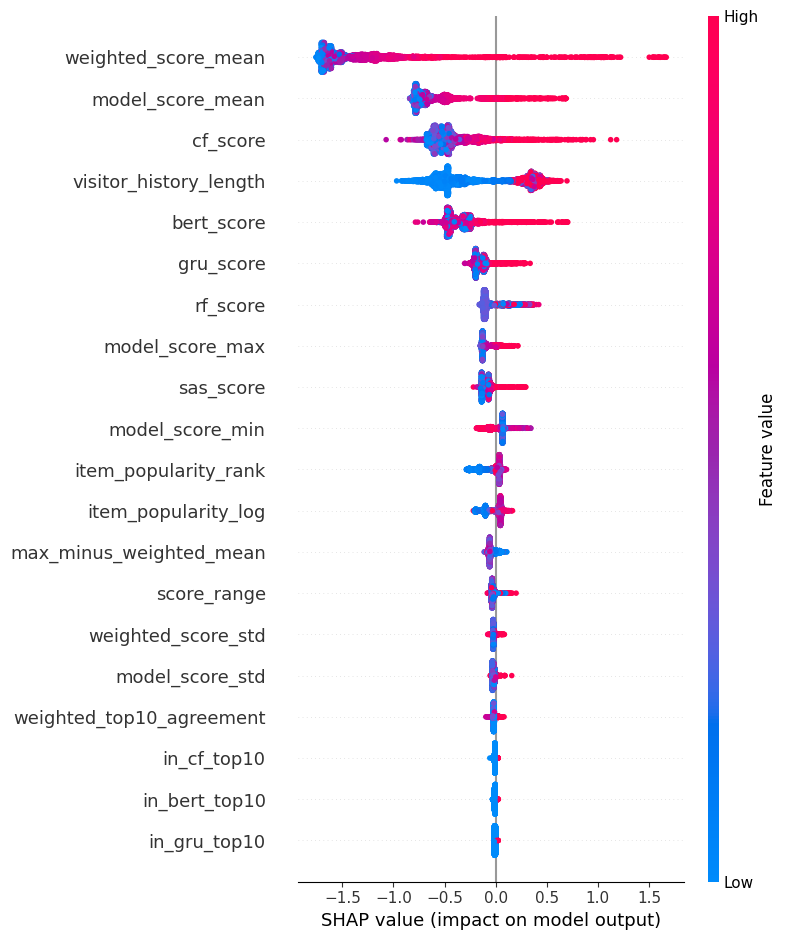

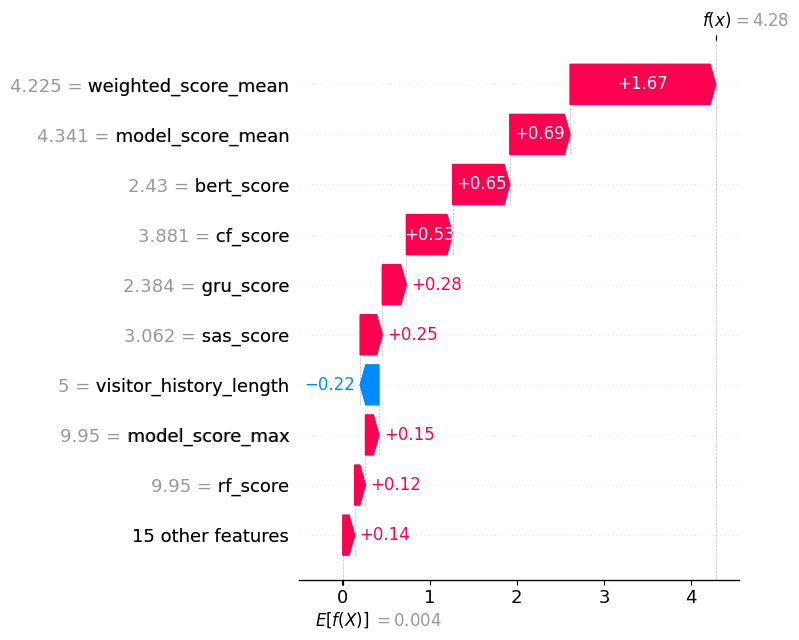

In [23]:
# ============================================================
# 22. SHAP ATTRIBUTION OF THE FINAL FROZEN RANKER
# ============================================================
import shap
import matplotlib.pyplot as plt

shap_sample = final_val_frame[FINAL_FEATURES].sample(
    min(5_000, len(final_val_frame)), random_state=SEED
)
explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(shap_sample)

mean_abs = np.abs(shap_values).mean(axis=0)
shap_df = pd.DataFrame({
    "Feature":FINAL_FEATURES,
    "MeanAbsSHAP":mean_abs
}).sort_values("MeanAbsSHAP", ascending=False)
shap_df["RelativeImportance"] = shap_df["MeanAbsSHAP"] / shap_df["MeanAbsSHAP"].sum()

display(shap_df.head(25))
shap_df.to_csv(OUT_DIR/"kt4_common50k_shap_importance.csv", index=False)

shap.summary_plot(shap_values, shap_sample, show=False)
plt.tight_layout()
plt.savefig(OUT_DIR/"kt4_common50k_shap_summary.png", dpi=600, bbox_inches="tight")
plt.show()

# Local explanation for a representative positive candidate.
positive_rows = final_test_frame[final_test_frame.label==1]
rep_idx = positive_rows.index[len(positive_rows)//2]
rep_x = final_test_frame.loc[[rep_idx], FINAL_FEATURES]
rep_sv = explainer(rep_x)
shap.plots.waterfall(rep_sv[0], show=False)
plt.tight_layout()
plt.savefig(OUT_DIR/"kt4_common50k_shap_waterfall.png", dpi=600, bbox_inches="tight")
plt.show()

In [24]:
# ============================================================
# 23. ROBUSTNESS BY PRE-TEST HISTORY LENGTH
# ============================================================
def history_group(n):
    if n <= 5: return "Very Short (<=5)"
    if n <= 20: return "Short (6-20)"
    if n <= 50: return "Medium (21-50)"
    return "Long (>50)"

pretest_len = {int(u): len(test_history[int(u)]) for u in eval_users}

rob_rows = []
for model, d in per_user.items():
    x = d.copy()
    x["HistoryGroup"] = x.user_idx.map(lambda u: history_group(pretest_len[int(u)]))
    for grp, g in x.groupby("HistoryGroup"):
        for metric in ["hr","ndcg","mrr"]:
            if len(g) >= 2:
                lo, hi = bootstrap_ci(g[metric].values, n_boot=1000, seed=SEED+len(rob_rows)+900)
            else:
                lo, hi = np.nan, np.nan
            rob_rows.append({
                "Model":model, "HistoryGroup":grp, "Metric":metric,
                "Mean":g[metric].mean(), "CI_low":lo, "CI_high":hi,
                "Users":len(g), "Reliable_n_ge_30":len(g)>=30
            })

robustness_df = pd.DataFrame(rob_rows)
display(robustness_df[robustness_df.Metric=="ndcg"])
robustness_df.to_csv(OUT_DIR/"kt4_common50k_history_robustness.csv", index=False)

,Model,HistoryGroup,Metric,Mean,CI_low,CI_high,Users,Reliable_n_ge_30
1,CF,Medium (21-50),ndcg,0.657812,0.637057,0.678976,1529,True
4,CF,Short (6-20),ndcg,0.684034,0.667375,0.702114,1858,True
7,CF,Very Short (<=5),ndcg,0.645950,0.629894,0.663744,1613,True
10,RF,Medium (21-50),ndcg,0.591862,0.568469,0.613411,1529,True
13,RF,Short (6-20),ndcg,0.621835,0.601822,0.641387,1858,True
16,RF,Very Short (<=5),ndcg,0.611516,0.589321,0.633496,1613,True
19,GRU4Rec,Medium (21-50),ndcg,0.468999,0.445104,0.491360,1529,True
22,GRU4Rec,Short (6-20),ndcg,0.677559,0.660141,0.694713,1858,True
25,GRU4Rec,Very Short (<=5),ndcg,0.783639,0.770061,0.796242,1613,True
28,SASRec,Medium (21-50),ndcg,0.487579,0.464436,0.509536,1529,True


In [25]:
# ============================================================
# 24. CONTROLLED NEURAL DATA-SCALING DIAGNOSTIC
# ============================================================
# This section quantifies training-population sensitivity under a fixed short diagnostic regime.
# It does NOT replace the principal baseline table.

def diagnostic_user_subset(n_users):
    # Nested deterministic subsets from the already-frozen common cohort, stratified implicitly
    # by taking a fixed RNG permutation once.
    return scaling_user_order[:int(n_users)]

def cases_for_users(users):
    user_set = set(map(int, users))
    seqs = {u: common_train_seq[u] for u in user_set}
    return build_prefix_cases(seqs, MAX_PREFIXES_PER_LEARNER)

def eval_neural_model(model_name, model, eval_subset):
    rows = []
    for r in eval_subset.itertuples(index=False):
        uid = int(r.user_idx)
        cand = val_candidates[uid]
        hist = val_history[uid]
        truth = int(r.item_idx)
        if model_name == "GRU4Rec":
            s = torch.tensor([right_pad(hist, GRU_MAX_LEN)], dtype=torch.long, device=DEVICE)
            model.eval()
            with torch.no_grad(): logits = model(s)[0]
        elif model_name == "SASRec":
            s = torch.tensor([right_pad(hist, SAS_MAX_LEN)], dtype=torch.long, device=DEVICE)
            model.eval()
            with torch.no_grad(): logits = model(s)[0]
        else:
            prefix = [int(x) for x in hist[-(BERT_MAX_LEN-1):]]
            arr = prefix + [MASK_IDX] + [0]*(BERT_MAX_LEN-len(prefix)-1)
            pos = len(prefix)
            s = torch.tensor([arr], dtype=torch.long, device=DEVICE)
            p = torch.tensor([pos], dtype=torch.long, device=DEVICE)
            model.eval()
            with torch.no_grad(): logits = model(s,p)[0]
        idx = torch.tensor(cand, dtype=torch.long, device=DEVICE)
        scores = logits[idx].detach().cpu().numpy()
        pred = topk_from_scores(cand, scores, TOPK)
        rows.append(per_query_metrics(pred, truth, TOPK))
    d = pd.DataFrame(rows)
    return d[["hr","ndcg","mrr"]].mean()

scaling_rows = []

if RUN_SCALING_DIAGNOSTIC:
    rr = np.random.default_rng(SEED + 333)
    scaling_user_order = rr.permutation(common_users)

    # Fixed diagnostic evaluation subset from the 5,000 validation queries.
    diagnostic_eval_users = np.sort(
        np.random.default_rng(SEED+334).choice(
            eval_users, size=min(SCALING_EVAL_USERS, len(eval_users)), replace=False
        )
    )
    diagnostic_eval = val_eval[val_eval.user_idx.isin(diagnostic_eval_users)].copy()

    for n_users in SCALING_COHORTS:
        users = diagnostic_user_subset(n_users)
        cases = cases_for_users(users)
        n_interactions = int(
            common_train_df[common_train_df.user_idx.isin(users)].shape[0]
        )

        # GRU diagnostic
        ds = PrefixDataset(cases, GRU_MAX_LEN)
        dl = DataLoader(ds, batch_size=GRU_BATCH, shuffle=True, num_workers=0)
        m = GRU4RecModel(n_items).to(DEVICE)
        o = torch.optim.Adam(m.parameters(), lr=1e-3)
        c = nn.CrossEntropyLoss()
        for ep in range(SCALING_EPOCHS):
            m.train()
            for s,t in dl:
                s,t=s.to(DEVICE),t.to(DEVICE)
                o.zero_grad(set_to_none=True)
                loss=c(m(s),t); loss.backward()
                nn.utils.clip_grad_norm_(m.parameters(),1.0); o.step()
        sm = eval_neural_model("GRU4Rec",m,diagnostic_eval)
        scaling_rows.append(["GRU4Rec",n_users,n_interactions,len(cases),*sm.tolist()])
        del m, ds, dl; gc.collect()
        if torch.cuda.is_available(): torch.cuda.empty_cache()

        # SAS diagnostic
        ds = PrefixDataset(cases, SAS_MAX_LEN)
        dl = DataLoader(ds, batch_size=SAS_BATCH, shuffle=True, num_workers=0)
        m = SASRecModel(n_items).to(DEVICE)
        o = torch.optim.AdamW(m.parameters(), lr=1e-3, weight_decay=1e-5)
        c = nn.CrossEntropyLoss()
        for ep in range(SCALING_EPOCHS):
            m.train()
            for s,t in dl:
                s,t=s.to(DEVICE),t.to(DEVICE)
                o.zero_grad(set_to_none=True)
                loss=c(m(s),t); loss.backward()
                nn.utils.clip_grad_norm_(m.parameters(),1.0); o.step()
        sm = eval_neural_model("SASRec",m,diagnostic_eval)
        scaling_rows.append(["SASRec",n_users,n_interactions,len(cases),*sm.tolist()])
        del m, ds, dl; gc.collect()
        if torch.cuda.is_available(): torch.cuda.empty_cache()

        # BERT-style diagnostic
        ds = BERTTerminalDataset(cases)
        dl = DataLoader(ds, batch_size=BERT_BATCH, shuffle=True, num_workers=0)
        m = BERT4RecStyleModel(n_items).to(DEVICE)
        o = torch.optim.AdamW(m.parameters(), lr=1e-3, weight_decay=1e-5)
        c = nn.CrossEntropyLoss()
        for ep in range(SCALING_EPOCHS):
            m.train()
            for s,p,t in dl:
                s,p,t=s.to(DEVICE),p.to(DEVICE),t.to(DEVICE)
                o.zero_grad(set_to_none=True)
                loss=c(m(s,p),t); loss.backward()
                nn.utils.clip_grad_norm_(m.parameters(),1.0); o.step()
        sm = eval_neural_model("BERT4Rec-style",m,diagnostic_eval)
        scaling_rows.append(["BERT4Rec-style",n_users,n_interactions,len(cases),*sm.tolist()])
        del m, ds, dl; gc.collect()
        if torch.cuda.is_available(): torch.cuda.empty_cache()

        # Release cohort-specific Python prefix structures before the next cohort.
        del cases, users
        gc.collect()
        if torch.cuda.is_available(): torch.cuda.empty_cache()

    scaling_df = pd.DataFrame(
        scaling_rows,
        columns=["Model","Visitors","TrainingInteractions","PositivePrefixCases","HR@10","NDCG@10","MRR@10"]
    )
    display(scaling_df)
    scaling_df.to_csv(OUT_DIR/"kt4_common50k_neural_scaling.csv", index=False)
else:
    scaling_df = pd.DataFrame()
    print("Scaling diagnostic disabled.")

,Model,Visitors,TrainingInteractions,PositivePrefixCases,HR@10,NDCG@10,MRR@10
0,GRU4Rec,10000,174623,19741,0.717,0.547446,0.493425
1,SASRec,10000,174623,19741,0.694,0.532078,0.480623
2,BERT4Rec-style,10000,174623,19741,0.677,0.506307,0.452210
3,GRU4Rec,25000,433687,49328,0.749,0.584179,0.531330
4,SASRec,25000,433687,49328,0.740,0.591123,0.544104
5,BERT4Rec-style,25000,433687,49328,0.710,0.527121,0.469057
6,GRU4Rec,50000,870981,98660,0.794,0.638738,0.589103
7,SASRec,50000,870981,98660,0.796,0.654048,0.608295
8,BERT4Rec-style,50000,870981,98660,0.775,0.622773,0.573802


In [26]:
# ============================================================
# 25. COMPUTATIONAL EFFICIENCY AND MODEL SIZE
# ============================================================
def model_size_mb(obj):
    with tempfile.NamedTemporaryFile(delete=False, suffix=".bin") as f:
        path = f.name
    try:
        if isinstance(obj, nn.Module):
            torch.save(obj.state_dict(), path)
        else:
            with open(path, "wb") as g:
                pickle.dump(obj, g)
        return os.path.getsize(path)/(1024**2)
    finally:
        try: os.remove(path)
        except: pass

def torch_params(m):
    return sum(p.numel() for p in m.parameters())

def benchmark_scorer(fn, n_queries=300):
    vals = []
    subset = test_eval.head(min(n_queries, len(test_eval)))
    for r in subset.itertuples(index=False):
        uid = int(r.user_idx)
        cand = test_candidates[uid]
        hist = test_history[uid]
        if torch.cuda.is_available(): torch.cuda.synchronize()
        st = time.perf_counter()
        fn(uid, cand, hist)
        if torch.cuda.is_available(): torch.cuda.synchronize()
        vals.append((time.perf_counter()-st)*1000)
    return float(np.mean(vals)), float(np.percentile(vals,95))

lat = {}
for name, fn in [
    ("CF",cf_score),("RF",rf_score),("GRU4Rec",gru_score),
    ("SASRec",sas_score),("BERT4Rec-style",bert_score)
]:
    lat[name] = benchmark_scorer(fn)

def benchmark_ranker(n_queries=300):
    vals=[]
    groups=list(final_test_frame.groupby("query_id",sort=True))[:n_queries]
    for _,g in groups:
        st=time.perf_counter()
        xgb_model.predict(g[FINAL_FEATURES])
        vals.append((time.perf_counter()-st)*1000)
    return float(np.mean(vals)), float(np.percentile(vals,95))

lat["XGBRanker"] = benchmark_ranker()

training_times = {
    "CF":cf_train_time, "RF":rf_train_time, "GRU4Rec":gru_train_time,
    "SASRec":sas_train_time, "BERT4Rec-style":bert_train_time,
    "XGBRanker":xgb_train_time
}

objs = {
    "RF":rf_model, "GRU4Rec":gru_model, "SASRec":sas_model,
    "BERT4Rec-style":bert_model, "XGBRanker":xgb_model
}

eff_rows=[]
for name in ["CF","RF","GRU4Rec","SASRec","BERT4Rec-style","XGBRanker"]:
    obj=objs.get(name)
    params=torch_params(obj) if isinstance(obj,nn.Module) else np.nan
    trees=(
        len(obj.estimators_) if name=="RF"
        else (len(obj.get_booster().get_dump()) if name=="XGBRanker" else np.nan)
    )
    size=model_size_mb(obj) if obj is not None else np.nan
    meanlat,p95=lat[name]
    gpu_peak={
        "GRU4Rec":gru_peak_gpu_mb,
        "SASRec":sas_peak_gpu_mb,
        "BERT4Rec-style":bert_peak_gpu_mb
    }.get(name,np.nan)
    eff_rows.append([
        name,training_times[name],meanlat,p95,size,params,trees,gpu_peak
    ])

efficiency_df=pd.DataFrame(eff_rows,columns=[
    "Model","TrainingSeconds","MeanQueryLatencyMs","P95QueryLatencyMs",
    "SerializedSizeMB","Parameters","TreeCount","PeakGPUAllocatedMB"
])

complete = pd.DataFrame([{
    "Model":"Complete Hybrid",
    "TrainingSeconds":sum(training_times.values()),
    "MeanQueryLatencyMs":sum(lat[n][0] for n in ["CF","RF","GRU4Rec","SASRec","BERT4Rec-style","XGBRanker"]),
    "P95QueryLatencyMs":np.nan,
    "SerializedSizeMB":sum(model_size_mb(objs[n]) for n in objs),
    "Parameters":sum(torch_params(m) for m in [gru_model,sas_model,bert_model]),
    "TreeCount":len(rf_model.estimators_)+len(xgb_model.get_booster().get_dump()),
    "PeakGPUAllocatedMB":np.nan
}])

efficiency_df=pd.concat([efficiency_df,complete],ignore_index=True)
display(efficiency_df)
efficiency_df.to_csv(OUT_DIR/"kt4_common50k_efficiency.csv",index=False)

,Model,TrainingSeconds,MeanQueryLatencyMs,P95QueryLatencyMs,SerializedSizeMB,Parameters,TreeCount,PeakGPUAllocatedMB
0,CF,1.047840,1.864910,2.607179,NaN,NaN,NaN,NaN
1,RF,9.976222,34.705864,38.076813,3.664336,NaN,120.0,NaN
2,GRU4Rec,167.800434,0.761338,0.852666,5.164983,1353266.0,NaN,47.166504
3,SASRec,138.929430,1.708441,2.583453,7.787181,2039746.0,NaN,74.119629
4,BERT4Rec-style,324.418761,1.857005,2.020900,5.196544,1360626.0,NaN,69.609863
5,XGBRanker,14.928158,3.639871,4.194865,0.726105,NaN,300.0,NaN
6,Complete Hybrid,657.100845,44.537429,NaN,22.539148,4753638.0,420.0,NaN


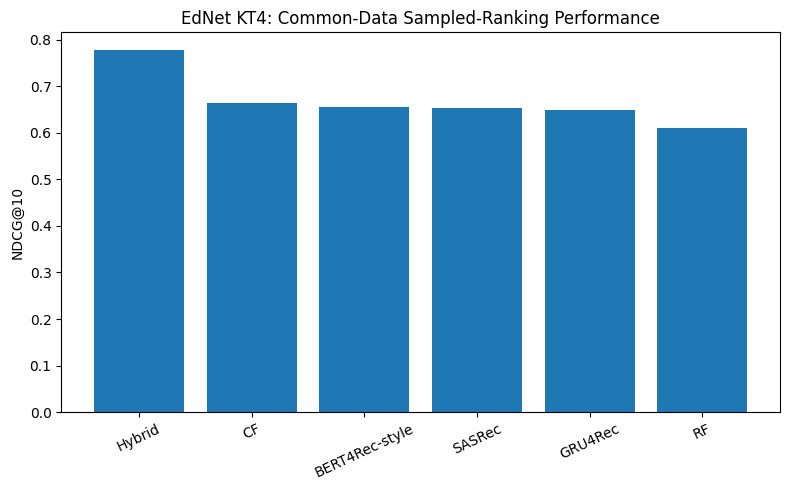

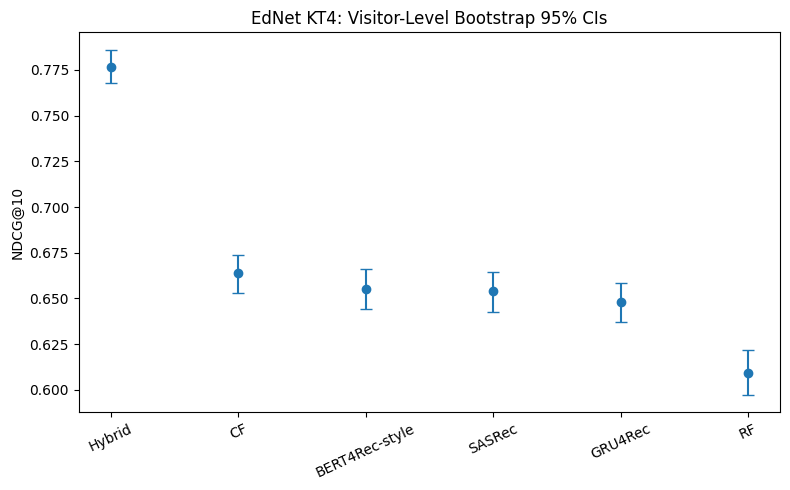

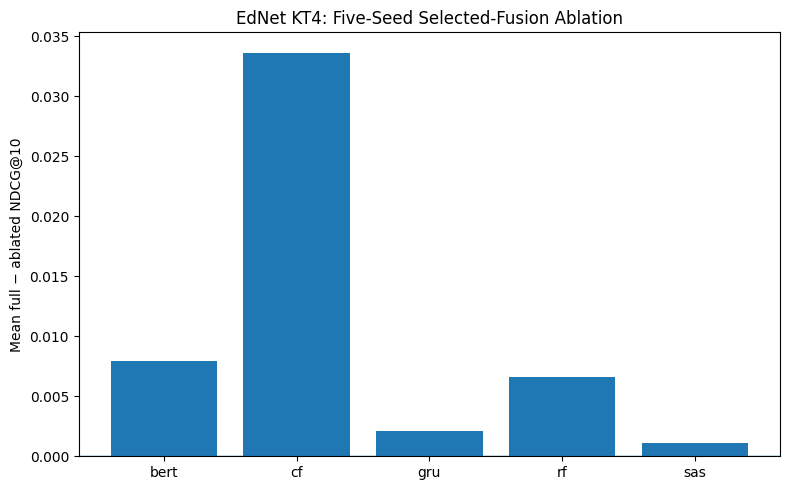

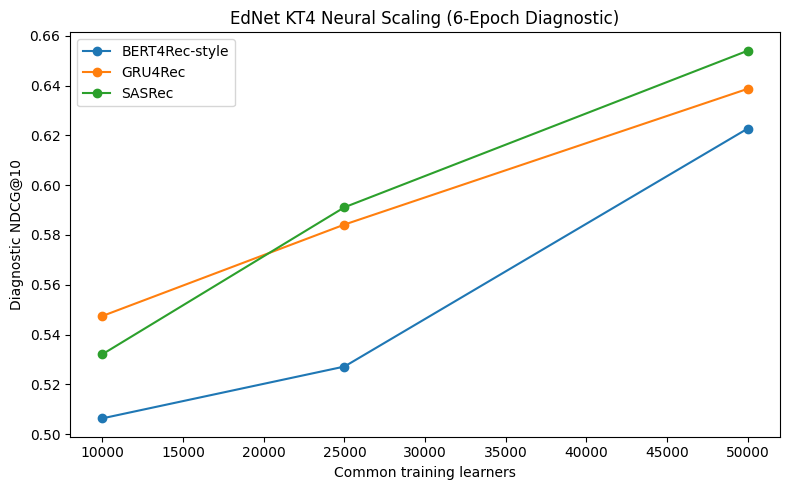

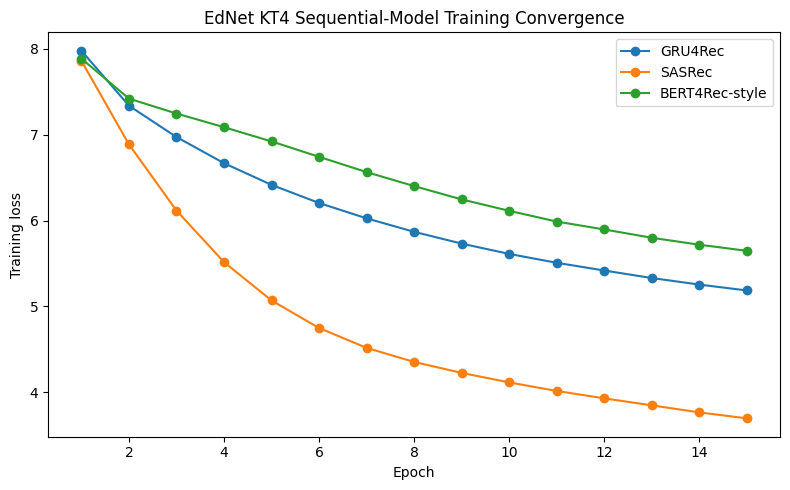

In [27]:
# ============================================================
# 26. PUBLICATION FIGURES
# ============================================================
import matplotlib.pyplot as plt

# Main performance
p = results_df.sort_values("NDCG@10", ascending=False)
fig, ax = plt.subplots(figsize=(8,5))
ax.bar(p.Model, p["NDCG@10"])
ax.set_ylabel("NDCG@10")
ax.set_title("EdNet KT4: Common-Data Sampled-Ranking Performance")
ax.tick_params(axis="x", rotation=25)
fig.tight_layout()
fig.savefig(OUT_DIR/"kt4_common50k_main_ndcg.png", dpi=600, bbox_inches="tight")
plt.show()

# NDCG confidence intervals
nci = ci_df[ci_df.Metric=="ndcg"].copy().sort_values("Mean",ascending=False)
yerr = np.vstack([nci["Mean"]-nci["CI_low"], nci["CI_high"]-nci["Mean"]])
fig, ax = plt.subplots(figsize=(8,5))
ax.errorbar(nci["Model"], nci["Mean"], yerr=yerr, fmt="o", capsize=4)
ax.set_ylabel("NDCG@10")
ax.set_title("EdNet KT4: Visitor-Level Bootstrap 95% CIs")
ax.tick_params(axis="x",rotation=25)
fig.tight_layout()
fig.savefig(OUT_DIR/"kt4_common50k_ndcg_ci.png",dpi=600,bbox_inches="tight")
plt.show()

# Repeated-seed ablation
if not ablation_summary.empty:
    fig,ax=plt.subplots(figsize=(8,5))
    ax.bar(ablation_summary["AblatedComponent"],ablation_summary["MeanFullMinusVariantNDCG"])
    ax.axhline(0,linewidth=1)
    ax.set_ylabel("Mean full − ablated NDCG@10")
    ax.set_title("EdNet KT4: Five-Seed Selected-Fusion Ablation")
    fig.tight_layout()
    fig.savefig(OUT_DIR/"kt4_common50k_ablation_ndcg.png",dpi=600,bbox_inches="tight")
    plt.show()

# Neural scaling
if RUN_SCALING_DIAGNOSTIC and not scaling_df.empty:
    fig,ax=plt.subplots(figsize=(8,5))
    for model,g in scaling_df.groupby("Model"):
        g=g.sort_values("Visitors")
        ax.plot(g["Visitors"],g["NDCG@10"],marker="o",label=model)
    ax.set_xlabel("Common training learners")
    ax.set_ylabel("Diagnostic NDCG@10")
    ax.set_title(f"EdNet KT4 Neural Scaling ({SCALING_EPOCHS}-Epoch Diagnostic)")
    ax.legend()
    fig.tight_layout()
    fig.savefig(OUT_DIR/"kt4_common50k_neural_scaling.png",dpi=600,bbox_inches="tight")
    plt.show()

# Training convergence
fig,ax=plt.subplots(figsize=(8,5))
ax.plot(range(1,len(gru_losses)+1),gru_losses,marker="o",label="GRU4Rec")
ax.plot(range(1,len(sas_losses)+1),sas_losses,marker="o",label="SASRec")
ax.plot(range(1,len(bert_losses)+1),bert_losses,marker="o",label="BERT4Rec-style")
ax.set_xlabel("Epoch")
ax.set_ylabel("Training loss")
ax.set_title("EdNet KT4 Sequential-Model Training Convergence")
ax.legend()
fig.tight_layout()
fig.savefig(OUT_DIR/"kt4_common50k_training_convergence.png",dpi=600,bbox_inches="tight")
plt.show()

In [28]:
# ============================================================
# 27. FINAL FAIRNESS / LEAKAGE / REPRODUCIBILITY GATE
# ============================================================
def user_hash(users):
    arr = np.array(sorted(set(map(int, users))), dtype=np.int64)
    return hashlib.sha256(",".join(map(str, arr.tolist())).encode("utf-8")).hexdigest()

cf_training_users = common_train_df["user_idx"].astype(int).unique()
rf_training_users = np.array(sorted({int(uid) for uid, _, _ in common_prefix_cases}), dtype=np.int64)
gru_training_users = rf_training_users.copy()
sas_training_users = rf_training_users.copy()
bert_training_users = rf_training_users.copy()

model_train_hashes = {
    "CF": user_hash(cf_training_users),
    "RF": user_hash(rf_training_users),
    "GRU4Rec": user_hash(gru_training_users),
    "SASRec": user_hash(sas_training_users),
    "BERT4Rec-style": user_hash(bert_training_users),
}

# Because the common cohort requires >=2 training events, every selected learner
# contributes at least one supervised prefix to RF and each neural family.
assert all(len(set(x)) == COMMON_LEARNERS for x in [
    cf_training_users, rf_training_users, gru_training_users, sas_training_users, bert_training_users
])

rf_positive_cases = int((rf_train.label==1).sum())
neural_positive_cases = len(common_prefix_cases)

validity_gate = pd.DataFrame([
    ["KT4 task transformation explicit", True],
    ["Per-learner chronological leave-two-out", True],
    ["Common 50k cohort selected from training information only", True],
    ["Same actual training-visitor hash for all five baseline families", len(set(model_train_hashes.values()))==1],
    ["Same bounded training histories define all model evidence", True],
    ["RF/neural positive prefix-case counts identical", rf_positive_cases==neural_positive_cases],
    ["RF features temporal-prefix safe", True],
    ["Common training catalogue defines all negatives", True],
    ["Exactly 1 positive + 99 negatives per query", True],
    ["Same cached candidates for every model", True],
    ["Validation target excluded from test negatives", True],
    ["Reliability estimated from 4k fusion-fit validation queries", True],
    ["Backward selection restricted to 1k validation-selection queries", True],
    ["Final component set frozen before final test evaluation", True],
    ["Final ranker refit on validation only", True],
    ["Repeated-seed ablation retrains ranker", True],
    ["Paired statistics + bootstrap + Holm + effect size", True],
    ["Popularity controls included", True],
    ["SHAP attribution included", True],
    ["History-length robustness included", True],
    ["Computational efficiency included", True],
    ["Controlled neural scaling diagnostic included", bool(RUN_SCALING_DIAGNOSTIC)],
], columns=["ValidityCheck","Passed"])

display(validity_gate)
assert validity_gate["Passed"].all(), "At least one final validity gate failed."

fingerprints = {
    "common_cohort_sha256": COMMON_COHORT_SHA256,
    "common_history_sha256": COMMON_HISTORY_SHA256,
    "evaluation_users_sha256": EVAL_USERS_SHA256,
    "common_learners": int(COMMON_LEARNERS),
    "common_history_cap": int(COMMON_MAX_HISTORY),
    "common_prefix_cases": int(len(common_prefix_cases)),
    "selected_components": SELECTED_COMPONENTS,
    "final_feature_count": int(len(FINAL_FEATURES)),
    "ranker_objective": RANKER_PARAMS["objective"],
}
with open(OUT_DIR/"kt4_common50k_fingerprints.json","w",encoding="utf-8") as f:
    json.dump(fingerprints,f,indent=2)

validity_gate.to_csv(OUT_DIR/"kt4_common50k_validity_gate.csv",index=False)
print(json.dumps(fingerprints,indent=2))
print("FINAL OUTPUT DIRECTORY:", OUT_DIR)

,ValidityCheck,Passed
0,KT4 task transformation explicit,True
1,Per-learner chronological leave-two-out,True
2,Common 50k cohort selected from training infor...,True
3,Same actual training-visitor hash for all five...,True
4,Same bounded training histories define all mod...,True
5,RF/neural positive prefix-case counts identical,True
6,RF features temporal-prefix safe,True
7,Common training catalogue defines all negatives,True
8,Exactly 1 positive + 99 negatives per query,True
9,Same cached candidates for every model,True


{
  "common_cohort_sha256": "20d955083da5e4d754ae1b14007c11708069624d60d6177d37831503bd7fc543",
  "common_history_sha256": "f8d8bf4fc55c7e6525d1a7ab68a52914b31f93c81f3e3cc160833df9fdb53cc2",
  "evaluation_users_sha256": "307ac2f112d9392062abc26cd23de8c4fa971b44cd9c6e334ebada768a0c5d22",
  "common_learners": 50000,
  "common_history_cap": 50,
  "common_prefix_cases": 98660,
  "selected_components": [
    "cf",
    "rf",
    "gru",
    "sas",
    "bert"
  ],
  "final_feature_count": 24,
  "ranker_objective": "rank:ndcg"
}
FINAL OUTPUT DIRECTORY: /kaggle/working/ednet_kt4_common50k_publication_outputs


In [29]:
# ============================================================
# 28. ENVIRONMENT CAPTURE + MANUSCRIPT-READY RUN SUMMARY
# ============================================================
import subprocess

print("="*76)
print("FINAL EXECUTED ENVIRONMENT")
print("="*76)
print("Python:", sys.version)
print("Platform:", platform.platform())
print("PyTorch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
    print("CUDA version:", torch.version.cuda)

lock_file = OUT_DIR/"requirements-lock.txt"
with open(lock_file,"w",encoding="utf-8") as f:
    subprocess.run([sys.executable,"-m","pip","freeze"],stdout=f,check=True)

summary_lines = [
    "EDNET KT4 COMMON-DATA PUBLICATION SUMMARY",
    f"Common cohort: {COMMON_LEARNERS:,} learners",
    f"Common bounded train interactions: {len(common_train_df):,}",
    f"Common catalogue items: {len(train_catalog):,}",
    f"Common positive prefix cases: {len(common_prefix_cases):,}",
    f"Evaluation queries: {len(eval_users):,}",
    "Candidate protocol: 1 positive + 99 uniform unseen negatives from common train catalogue",
    f"Selected fusion components: {', '.join(SELECTED_COMPONENTS)}",
    f"Final fusion features: {len(FINAL_FEATURES)}",
    f"Common cohort SHA256: {COMMON_COHORT_SHA256}",
    f"Common history SHA256: {COMMON_HISTORY_SHA256}",
    f"Evaluation users SHA256: {EVAL_USERS_SHA256}",
    "",
    "MAIN RESULTS",
    results_df.to_string(index=False),
]
summary_text = "\n".join(summary_lines)
print(summary_text)

with open(OUT_DIR/"kt4_common50k_publication_summary.txt","w",encoding="utf-8") as f:
    f.write(summary_text)

print("\nExact package environment saved to:", lock_file)
print("="*76)

FINAL EXECUTED ENVIRONMENT
Python: 3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]
Platform: Linux-6.12.90+-x86_64-with-glibc2.35
PyTorch: 2.10.0+cu128
CUDA available: True
GPU: Tesla T4
CUDA version: 12.8
EDNET KT4 COMMON-DATA PUBLICATION SUMMARY
Common cohort: 50,000 learners
Common bounded train interactions: 870,981
Common catalogue items: 20,688
Common positive prefix cases: 98,660
Evaluation queries: 5,000
Candidate protocol: 1 positive + 99 uniform unseen negatives from common train catalogue
Selected fusion components: cf, rf, gru, sas, bert
Final fusion features: 24
Common cohort SHA256: 20d955083da5e4d754ae1b14007c11708069624d60d6177d37831503bd7fc543
Common history SHA256: f8d8bf4fc55c7e6525d1a7ab68a52914b31f93c81f3e3cc160833df9fdb53cc2
Evaluation users SHA256: 307ac2f112d9392062abc26cd23de8c4fa971b44cd9c6e334ebada768a0c5d22

MAIN RESULTS
         Model  Precision@10  Recall@10  HR@10  NDCG@10   MRR@10  Queries
        Hybrid       0.09016     0.9016 0.9016 0.776837 0.7363